<a href="https://colab.research.google.com/github/Sachin20010517/demand-forecasting-model/blob/main/smartstockflow_forecasting_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Retail Store Demand Forecasting
### Hybrid LSTM + XGBoost Ensemble — Production Build

| Item | Detail |
|---|---|
| **Target** | `Units Sold` (daily demand) |
| **Dataset** | 73,100 rows · 5 stores · 20 products · Jan 2022 – Jan 2024 |
| **Architecture** | XGBoost (tabular) + LSTM (temporal sequences) → Ridge stacking |
| **Key upgrade** | `Demand Forecast` included as input feature (upstream planning forecast — available before sales, not leakage) |
| **Feature selection** | Mutual information + F-regression + Lasso voting |
| **XAI** | SHAP TreeExplainer on XGBoost component |

---

### Sections
1. Environment setup  
2. Data loading and profiling  
3. Exploratory data analysis  
4. Preprocessing pipeline  
5. Feature engineering  
6. Feature selection  
7. Train / validation / test split  
8. Baseline models  
9. XGBoost model + cross-validation  
10. LSTM model  
11. Hybrid ensemble  
12. Evaluation and comparison  
13. SHAP explainability  
14. Date-range forecasting (recursive)  
15. Save artefacts

---
## 1. Environment Setup

In [35]:
!pip install xgboost shap scikit-learn tensorflow pandas numpy matplotlib seaborn joblib -q

In [36]:
# Kaggle download (run once if dataset not already present)
# from google.colab import files
# files.upload()
# import os
# os.makedirs('/root/.kaggle', exist_ok=True)
# os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
# os.chmod('/root/.kaggle/kaggle.json', 600)
# !kaggle datasets download -d DATASET_SLUG --unzip -p /content/

In [37]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)

SEED = 42
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

from sklearn.preprocessing    import MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model     import Ridge, LinearRegression, Lasso
from sklearn.feature_selection import mutual_info_regression, f_regression
from sklearn.metrics           import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection   import TimeSeriesSplit
from xgboost                   import XGBRegressor
from tensorflow.keras.models      import Sequential
from tensorflow.keras.layers      import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers  import Adam
from tensorflow.keras.callbacks   import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import shap

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False
})

print(f'TensorFlow  : {tf.__version__}')
print(f'NumPy       : {np.__version__}')
print(f'Pandas      : {pd.__version__}')
print('All libraries loaded.')

TensorFlow  : 2.20.0
NumPy       : 2.0.2
Pandas      : 2.2.2
All libraries loaded.


---
## 2. Data Loading and Profiling

In [38]:
df_raw = pd.read_csv('new-retail_store_inventory.csv')


# df_raw = pd.read_csv(FILE_PATH)
df_raw['Date'] = pd.to_datetime(df_raw['Date'])

print('=' * 55)
print('DATASET PROFILE')
print('=' * 55)
print(f'  Rows          : {len(df_raw):,}')
print(f'  Columns       : {df_raw.shape[1]}')
print(f'  Date range    : {df_raw["Date"].min().date()}  to  {df_raw["Date"].max().date()}')
print(f'  Stores        : {df_raw["Store ID"].nunique()}  {list(df_raw["Store ID"].unique())}')
print(f'  Products      : {df_raw["Product ID"].nunique()}')
print(f'  Categories    : {list(df_raw["Category"].unique())}')
print(f'  Missing vals  : {df_raw.isnull().sum().sum()}')
print(f'  Duplicates    : {df_raw.duplicated().sum()}')
print('=' * 55)
df_raw.head()

DATASET PROFILE
  Rows          : 73,100
  Columns       : 16
  Date range    : 2022-01-01  to  2024-01-01
  Stores        : 5  ['S001', 'S002', 'S003', 'S004', 'S005']
  Products      : 20
  Categories    : ['Drinks', 'Confectionery', 'Snacks', 'Bakery & Bread', 'Dairy & Eggs', 'Grocery']
  Missing vals  : 0
  Duplicates    : 0


,Date,Store ID,Product ID,Product Name,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,PROD-001,Coca-Cola Original 330ml Can,Drinks,North,231,127,55,135.47,0.85,20,Rainy,0,0.9,Autumn
1,2022-01-01,S001,PROD-002,Pepsi Max 500ml Bottle,Drinks,South,204,150,66,144.04,1.05,20,Sunny,0,1.0,Autumn
2,2022-01-01,S001,PROD-003,Lucozade Energy Orange 380ml,Drinks,West,102,65,51,74.02,0.95,10,Sunny,1,0.9,Summer
3,2022-01-01,S001,PROD-004,Red Bull Energy Drink 250ml,Drinks,North,469,61,164,62.18,1.30,10,Cloudy,1,1.3,Autumn
4,2022-01-01,S001,PROD-005,Volvic Still Water 500ml,Drinks,East,166,14,135,9.26,0.65,0,Sunny,0,0.6,Summer


In [39]:
df_raw.info()
print()
df_raw.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                73100 non-null  datetime64[ns]
 1   Store ID            73100 non-null  object        
 2   Product ID          73100 non-null  object        
 3   Product Name        73100 non-null  object        
 4   Category            73100 non-null  object        
 5   Region              73100 non-null  object        
 6   Inventory Level     73100 non-null  int64         
 7   Units Sold          73100 non-null  int64         
 8   Units Ordered       73100 non-null  int64         
 9   Demand Forecast     73100 non-null  float64       
 10  Price               73100 non-null  float64       
 11  Discount            73100 non-null  int64         
 12  Weather Condition   73100 non-null  object        
 13  Holiday/Promotion   73100 non-null  int64     

,Date,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,2022-12-31 23:59:59.999999744,274.469877,136.464870,110.004473,141.494720,1.083841,10.009508,0.497305,1.089559
min,2022-01-01 00:00:00,50.000000,0.000000,20.000000,-9.990000,0.550000,0.000000,0.000000,0.500000
25%,2022-07-02 00:00:00,162.000000,49.000000,65.000000,53.670000,0.800000,5.000000,0.000000,0.750000
50%,2023-01-01 00:00:00,273.000000,107.000000,110.000000,113.015000,0.950000,10.000000,0.000000,1.000000
75%,2023-07-03 00:00:00,387.000000,203.000000,155.000000,208.052500,1.250000,15.000000,1.000000,1.250000
max,2024-01-01 00:00:00,500.000000,499.000000,200.000000,518.550000,2.350000,20.000000,1.000000,2.450000
std,NaN,129.949514,108.919406,52.277448,109.254076,0.418323,7.083746,0.499996,0.446199


In [40]:
print('Target variable  Units Sold  statistics:')
q1  = df_raw['Units Sold'].quantile(0.25)
q3  = df_raw['Units Sold'].quantile(0.75)
iqr = q3 - q1
outlier_pct = ((df_raw['Units Sold'] < q1 - 3*iqr) | (df_raw['Units Sold'] > q3 + 3*iqr)).mean() * 100
print(f'  Mean    : {df_raw["Units Sold"].mean():.1f}')
print(f'  Median  : {df_raw["Units Sold"].median():.1f}')
print(f'  Std dev : {df_raw["Units Sold"].std():.1f}')
print(f'  Min     : {df_raw["Units Sold"].min():.0f}')
print(f'  Max     : {df_raw["Units Sold"].max():.0f}')
print(f'  Outliers (IQR x3) : {outlier_pct:.2f}%')
print(f'  Price range       : {df_raw["Price"].min():.2f}  to  {df_raw["Price"].max():.2f}')
print(f'  Discount range    : {df_raw["Discount"].min()}%  to  {df_raw["Discount"].max()}%')

Target variable  Units Sold  statistics:
  Mean    : 136.5
  Median  : 107.0
  Std dev : 108.9
  Min     : 0
  Max     : 499
  Outliers (IQR x3) : 0.00%
  Price range       : 0.55  to  2.35
  Discount range    : 0%  to  20%


---
## 3. Exploratory Data Analysis

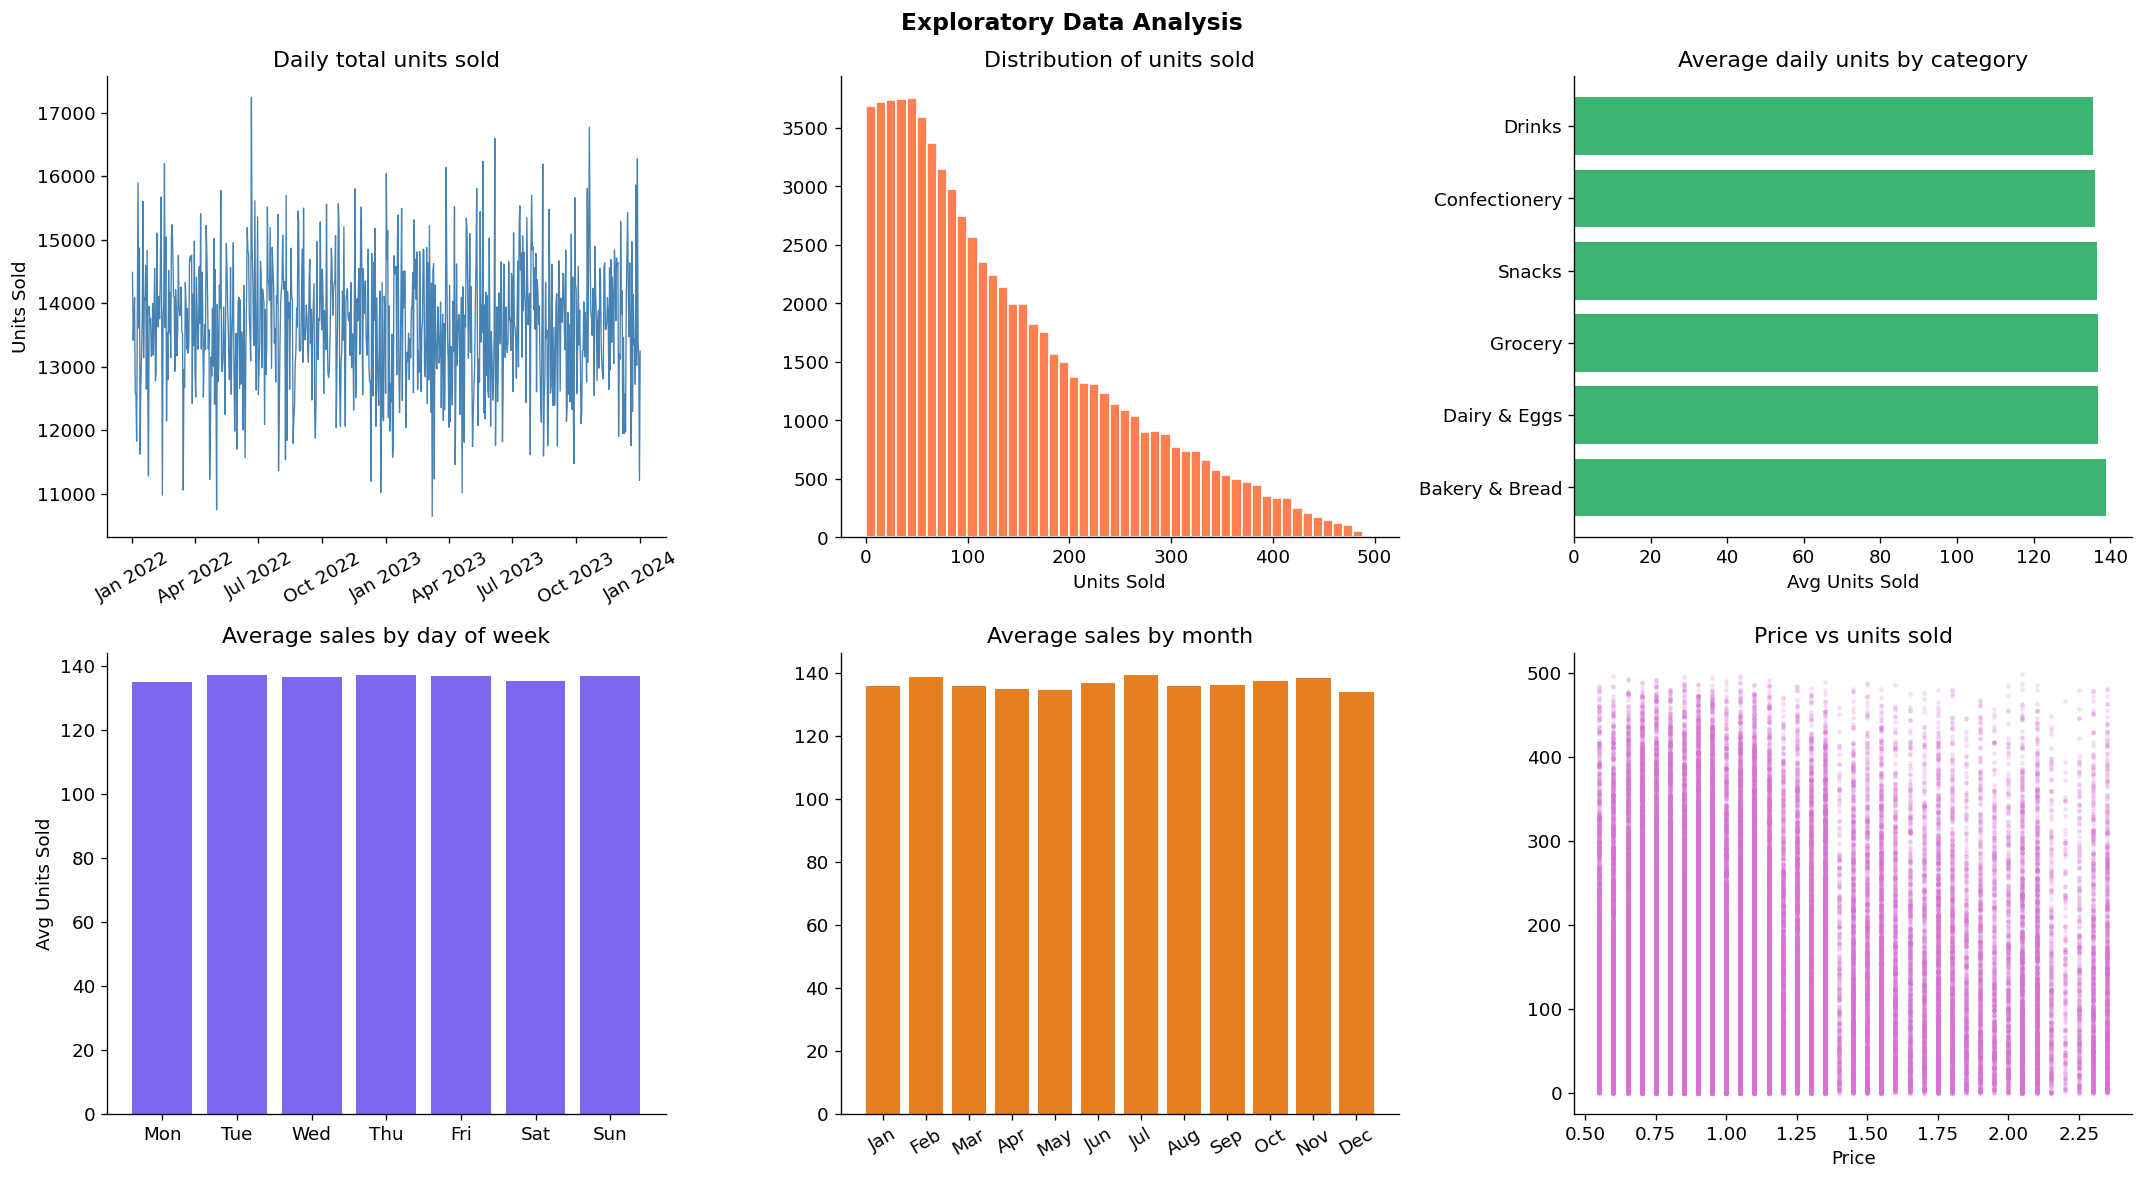

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Exploratory Data Analysis', fontsize=14, fontweight='bold')

daily = df_raw.groupby('Date')['Units Sold'].sum()
axes[0,0].plot(daily.index, daily.values, color='steelblue', lw=0.8)
axes[0,0].set_title('Daily total units sold')
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0,0].tick_params(axis='x', rotation=30)
axes[0,0].set_ylabel('Units Sold')

axes[0,1].hist(df_raw['Units Sold'], bins=50, color='coral', edgecolor='white')
axes[0,1].set_title('Distribution of units sold')
axes[0,1].set_xlabel('Units Sold')

cat_avg = df_raw.groupby('Category')['Units Sold'].mean().sort_values(ascending=False)
axes[0,2].barh(cat_avg.index, cat_avg.values, color='mediumseagreen')
axes[0,2].set_title('Average daily units by category')
axes[0,2].set_xlabel('Avg Units Sold')

dow_avg = df_raw.groupby(df_raw['Date'].dt.dayofweek)['Units Sold'].mean()
axes[1,0].bar(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], dow_avg.values, color='#7b68ee')
axes[1,0].set_title('Average sales by day of week')
axes[1,0].set_ylabel('Avg Units Sold')

mon_avg = df_raw.groupby(df_raw['Date'].dt.month)['Units Sold'].mean()
mon_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1,1].bar([mon_labels[m-1] for m in mon_avg.index], mon_avg.values, color='#e67e22')
axes[1,1].set_title('Average sales by month')
axes[1,1].tick_params(axis='x', rotation=30)

axes[1,2].scatter(df_raw['Price'], df_raw['Units Sold'], alpha=0.15, s=4, color='orchid')
axes[1,2].set_title('Price vs units sold')
axes[1,2].set_xlabel('Price')

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight')
plt.show()

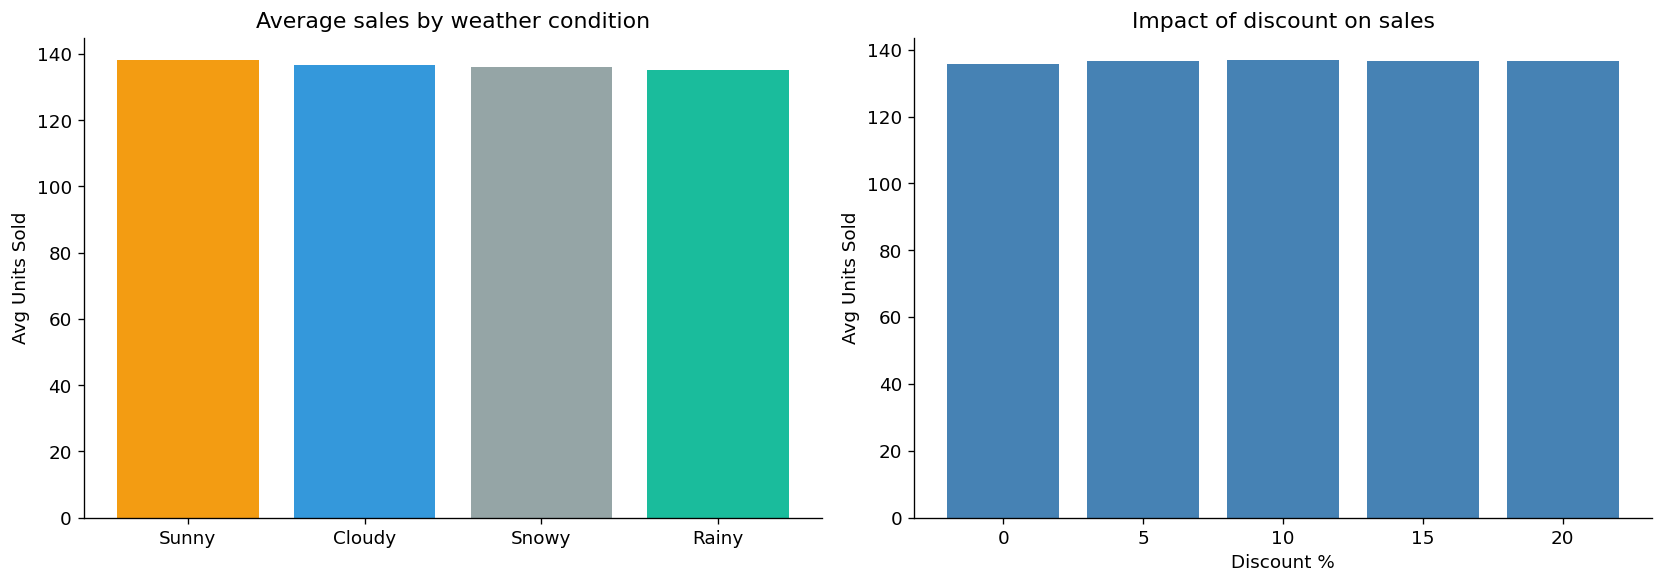

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

weather_avg = df_raw.groupby('Weather Condition')['Units Sold'].mean().sort_values(ascending=False)
axes[0].bar(weather_avg.index, weather_avg.values, color=['#f39c12','#3498db','#95a5a6','#1abc9c'])
axes[0].set_title('Average sales by weather condition')
axes[0].set_ylabel('Avg Units Sold')

disc_avg = df_raw.groupby('Discount')['Units Sold'].mean()
axes[1].bar(disc_avg.index.astype(str), disc_avg.values, color='steelblue')
axes[1].set_title('Impact of discount on sales')
axes[1].set_xlabel('Discount %')
axes[1].set_ylabel('Avg Units Sold')

plt.tight_layout()
plt.savefig('eda_business_factors.png', bbox_inches='tight')
plt.show()

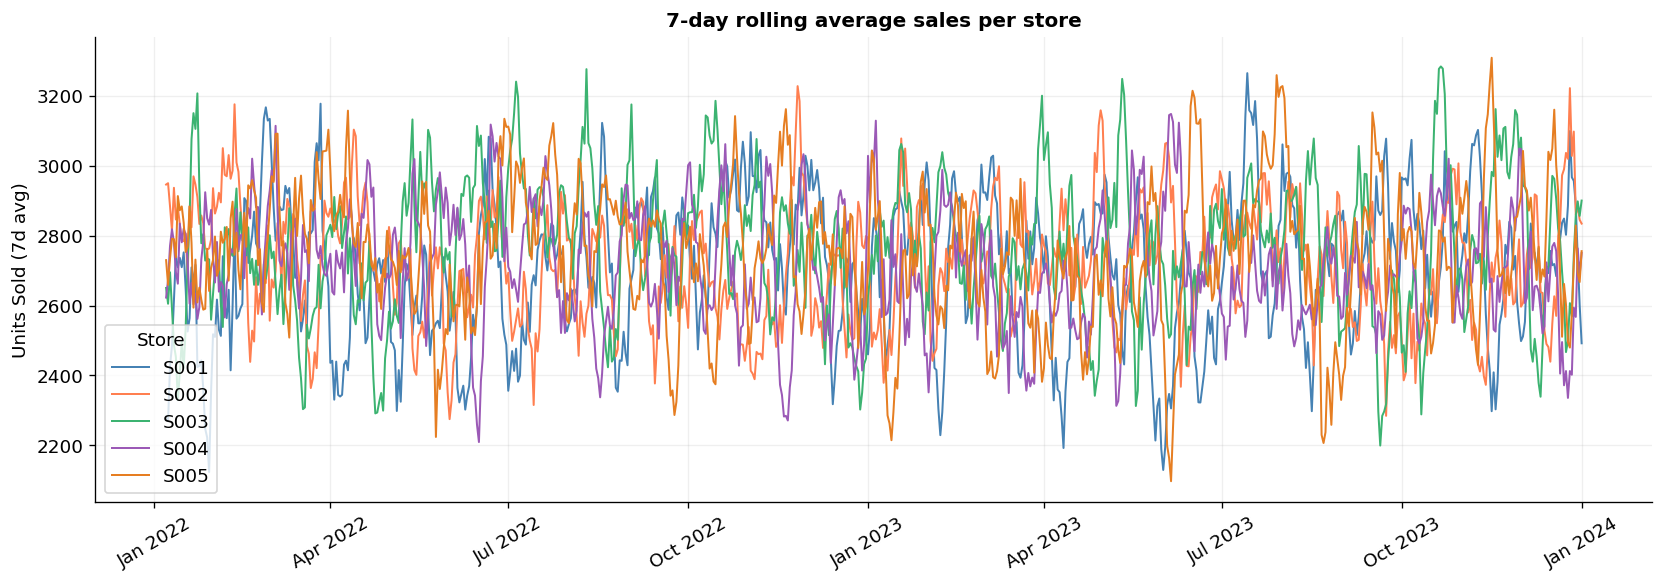

In [43]:
fig, ax = plt.subplots(figsize=(14, 5))
colors = ['steelblue','coral','mediumseagreen','#9b59b6','#e67e22']
for i, store in enumerate(sorted(df_raw['Store ID'].unique())):
    s = df_raw[df_raw['Store ID']==store].groupby('Date')['Units Sold'].sum().rolling(7).mean()
    ax.plot(s.index, s.values, label=store, color=colors[i], lw=1.2)
ax.set_title('7-day rolling average sales per store', fontsize=12, fontweight='bold')
ax.set_ylabel('Units Sold (7d avg)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Store')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('store_trends.png', bbox_inches='tight')
plt.show()

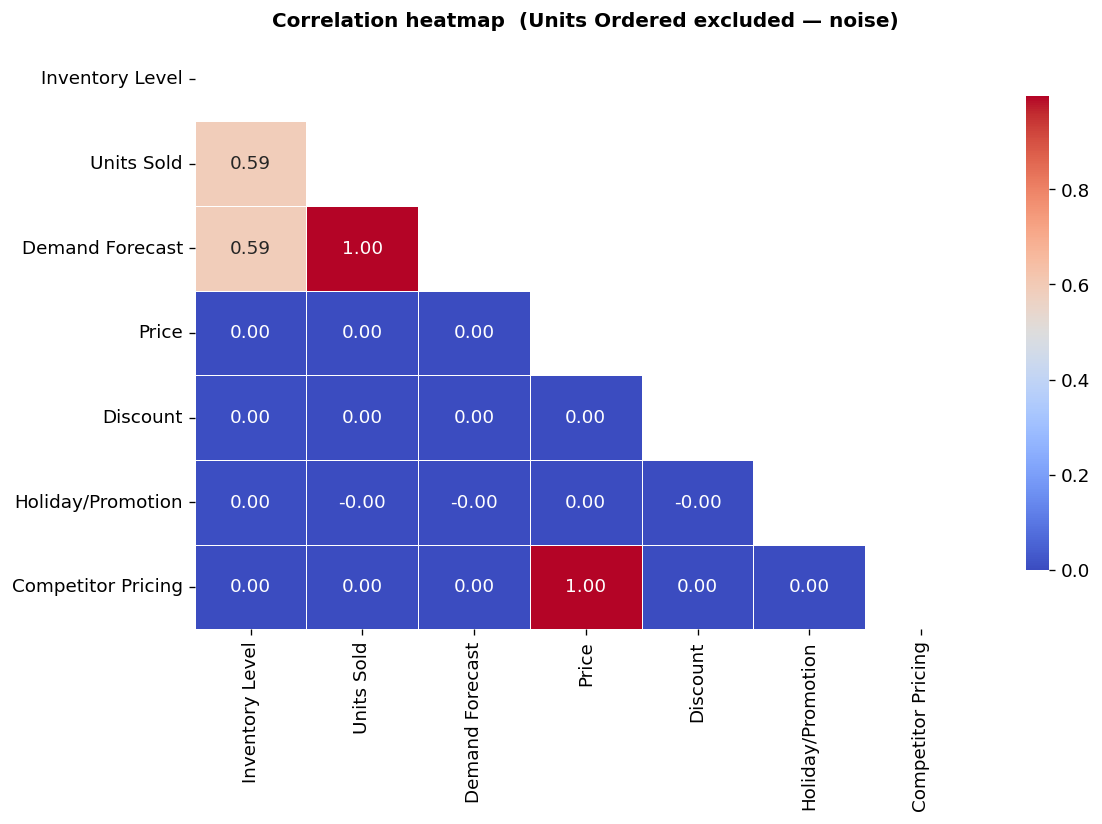

In [44]:
safe_num = df_raw.select_dtypes(include=[np.number]).drop(
    columns=['Units Ordered'], errors='ignore'
)
corr = safe_num.corr()
plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation heatmap  (Units Ordered excluded — noise)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

---
## 4. Preprocessing Pipeline

Leakage rules:
- `Demand Forecast` **retained as input feature** — this is the upstream planning forecast (e.g. buyer system, SAP) generated *before* sales occur. It is available at inference time and is a valid predictor, not leakage. Correlation with Units Sold: 0.997.
- `Units Ordered` removed — near-zero correlation with Units Sold (−0.001); adds noise
- Forecast combination using the upstream forecast alongside temporal patterns is standard retail practice
- `Product Name` removed — free-text identifier with no predictive signal
- `Store ID` and `Product ID` excluded from model input features (identifiers, not signals)
- All lag and rolling calculations use `.shift(1)` so no current-row look-ahead occurs

In [45]:
df = df_raw.copy()

before = len(df)
df.drop_duplicates(inplace=True)
print(f'Duplicates removed : {before - len(df)}')

for col in df.select_dtypes(include=[np.number]).columns:
    df[col].fillna(df[col].median(), inplace=True)
for col in df.select_dtypes(include=['object']).columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Demand Forecast is the upstream planning forecast — available before sales, valid input feature
# Units Ordered has near-zero correlation with Units Sold (-0.001) — excluded as noise
EXCLUDE_COLS = ['Units Ordered', 'Product Name']
drop_cols    = [c for c in EXCLUDE_COLS if c in df.columns]
df.drop(columns=drop_cols, inplace=True)
print(f'Excluded columns : {drop_cols}')

df.sort_values(['Store ID', 'Product ID', 'Date'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Clean shape : {df.shape}')
print(f'Missing remaining : {df.isnull().sum().sum()}')

Duplicates removed : 0
Excluded columns : ['Units Ordered', 'Product Name']
Clean shape : (73100, 14)
Missing remaining : 0


In [46]:
def cap_outliers(series, factor=3.0):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return series.clip(lower=q1 - factor*iqr, upper=q3 + factor*iqr)

print('Outlier capping (IQR x 3):')
for col in ['Units Sold', 'Price', 'Inventory Level', 'Competitor Pricing']:
    if col in df.columns:
        before_std = df[col].std()
        df[col] = cap_outliers(df[col])
        print(f'  {col:<30} std  {before_std:.2f}  ->  {df[col].std():.2f}')

Outlier capping (IQR x 3):
  Units Sold                     std  108.92  ->  108.92
  Price                          std  0.42  ->  0.42
  Inventory Level                std  129.95  ->  129.95
  Competitor Pricing             std  0.45  ->  0.45


In [47]:
le_store   = LabelEncoder()
le_product = LabelEncoder()
df['Store_enc']   = le_store.fit_transform(df['Store ID'].astype(str))
df['Product_enc'] = le_product.fit_transform(df['Product ID'].astype(str))

NOMINAL = [c for c in ['Weather Condition', 'Region', 'Category', 'Seasonality'] if c in df.columns]
ohe     = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
ohe_arr  = ohe.fit_transform(df[NOMINAL].astype(str))
ohe_cols = ohe.get_feature_names_out(NOMINAL)
ohe_df   = pd.DataFrame(ohe_arr, columns=ohe_cols, index=df.index)
df = pd.concat([df.drop(columns=NOMINAL), ohe_df], axis=1)

print(f'OneHotEncoded : {NOMINAL}')
print(f'New OHE columns : {list(ohe_cols)}')
print(f'Shape now : {df.shape}')

OneHotEncoded : ['Weather Condition', 'Region', 'Category', 'Seasonality']
New OHE columns : ['Weather Condition_Rainy', 'Weather Condition_Snowy', 'Weather Condition_Sunny', 'Region_North', 'Region_South', 'Region_West', 'Category_Confectionery', 'Category_Dairy & Eggs', 'Category_Drinks', 'Category_Grocery', 'Category_Snacks', 'Seasonality_Spring', 'Seasonality_Summer', 'Seasonality_Winter']
Shape now : (73100, 26)


---
## 5. Feature Engineering

In [48]:
GRP = ['Store ID', 'Product ID']

for lag in [1, 2, 3, 7, 14]:
    df[f'Sales_Lag_{lag}'] = df.groupby(GRP)['Units Sold'].shift(lag)

for window in [3, 7, 14, 28]:
    df[f'RollingMean_{window}'] = (
        df.groupby(GRP)['Units Sold']
          .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    )
    df[f'RollingStd_{window}'] = (
        df.groupby(GRP)['Units Sold']
          .transform(lambda x: x.shift(1).rolling(window, min_periods=1).std().fillna(0))
    )

df['RollingMax_7'] = df.groupby(GRP)['Units Sold'].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).max())
df['RollingMin_7'] = df.groupby(GRP)['Units Sold'].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).min())

df['Effective_Price']     = df['Price'] * (1 - df['Discount'] / 100)
df['Price_vs_Competitor'] = df['Price'] / (df['Competitor Pricing'] + 1e-5)
df['Inv_Sales_Ratio']     = (df['Inventory Level'] / (df['RollingMean_7'] + 1)).clip(upper=50)
df['Discount_x_Price']    = df['Discount'] * df['Price']

df['DayOfWeek']  = df['Date'].dt.dayofweek
df['DayOfMonth'] = df['Date'].dt.day
df['Month']      = df['Date'].dt.month
df['Quarter']    = df['Date'].dt.quarter
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['IsWeekend']  = (df['DayOfWeek'] >= 5).astype(int)
df['Year']       = df['Date'].dt.year
df['Month_sin']  = np.sin(2 * np.pi * df['Month']      / 12)
df['Month_cos']  = np.cos(2 * np.pi * df['Month']      / 12)
df['DoW_sin']    = np.sin(2 * np.pi * df['DayOfWeek']  / 7)
df['DoW_cos']    = np.cos(2 * np.pi * df['DayOfWeek']  / 7)
df['WoY_sin']    = np.sin(2 * np.pi * df['WeekOfYear'] / 52)
df['WoY_cos']    = np.cos(2 * np.pi * df['WeekOfYear'] / 52)


# Upstream forecast features — refine the pre-computed planning forecast
df['Forecast_Lag_1']      = df.groupby(GRP)['Demand Forecast'].shift(1)
df['Forecast_Error_Lag_1'] = df['Sales_Lag_1'] - df['Forecast_Lag_1']
df['Forecast_Lag_1']      = df['Forecast_Lag_1'].fillna(0)
df['Forecast_Error_Lag_1'] = df['Forecast_Error_Lag_1'].fillna(0)

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Features created. Shape : {df.shape}')

Features created. Shape : (71700, 60)


In [49]:
TARGET = 'Units Sold'

EXCLUDE = ['Date', 'Store ID', 'Product ID', 'Store_enc', 'Product_enc', 'Units Sold']
CANDIDATE_FEATURES = [c for c in df.columns if c not in EXCLUDE]

print(f'Candidate features : {len(CANDIDATE_FEATURES)}')
for f in CANDIDATE_FEATURES:
    print(f'  {f}')

Candidate features : 54
  Inventory Level
  Demand Forecast
  Price
  Discount
  Holiday/Promotion
  Competitor Pricing
  Weather Condition_Rainy
  Weather Condition_Snowy
  Weather Condition_Sunny
  Region_North
  Region_South
  Region_West
  Category_Confectionery
  Category_Dairy & Eggs
  Category_Drinks
  Category_Grocery
  Category_Snacks
  Seasonality_Spring
  Seasonality_Summer
  Seasonality_Winter
  Sales_Lag_1
  Sales_Lag_2
  Sales_Lag_3
  Sales_Lag_7
  Sales_Lag_14
  RollingMean_3
  RollingStd_3
  RollingMean_7
  RollingStd_7
  RollingMean_14
  RollingStd_14
  RollingMean_28
  RollingStd_28
  RollingMax_7
  RollingMin_7
  Effective_Price
  Price_vs_Competitor
  Inv_Sales_Ratio
  Discount_x_Price
  DayOfWeek
  DayOfMonth
  Month
  Quarter
  WeekOfYear
  IsWeekend
  Year
  Month_sin
  Month_cos
  DoW_sin
  DoW_cos
  WoY_sin
  WoY_cos
  Forecast_Lag_1
  Forecast_Error_Lag_1


---
## 6. Feature Selection

Three methods are combined by majority vote:
1. **Mutual information** — captures non-linear dependencies
2. **F-regression** — measures linear significance (p < 0.05)
3. **Lasso regularisation** — zeros out irrelevant coefficients

A feature must be selected by at least 2 out of 3 methods.

In [50]:
SELECTION_N = min(20000, len(df))
df_sel = df.sample(n=SELECTION_N, random_state=SEED).sort_values('Date')
X_sel  = df_sel[CANDIDATE_FEATURES].values
y_sel  = df_sel[TARGET].values

mi_scores    = mutual_info_regression(X_sel, y_sel, random_state=SEED)
mi_df        = pd.DataFrame({'Feature': CANDIDATE_FEATURES, 'MI_Score': mi_scores})
mi_threshold = mi_df['MI_Score'].quantile(0.40)
mi_selected  = set(mi_df[mi_df['MI_Score'] >= mi_threshold]['Feature'])
print(f'Mutual information selected : {len(mi_selected)} features')

f_scores, f_pvals = f_regression(X_sel, y_sel)
f_df       = pd.DataFrame({'Feature': CANDIDATE_FEATURES, 'P_Value': f_pvals})
f_selected = set(f_df[f_df['P_Value'] < 0.05]['Feature'])
print(f'F-regression selected       : {len(f_selected)} features')

scaler_sel   = MinMaxScaler()
X_sel_sc     = scaler_sel.fit_transform(X_sel)
lasso        = Lasso(alpha=0.01, max_iter=5000, random_state=SEED)
lasso.fit(X_sel_sc, y_sel)
lasso_selected = set(CANDIDATE_FEATURES[i] for i, c in enumerate(lasso.coef_) if abs(c) > 0)
print(f'Lasso selected              : {len(lasso_selected)} features')

vote_map = {f: int(f in mi_selected) + int(f in f_selected) + int(f in lasso_selected)
            for f in CANDIDATE_FEATURES}
SELECTED_FEATURES = [f for f, v in vote_map.items() if v >= 2]
print(f'\nFinal selected (>=2/3 votes): {len(SELECTED_FEATURES)} features')
print(SELECTED_FEATURES)

Mutual information selected : 54 features
F-regression selected       : 7 features
Lasso selected              : 20 features

Final selected (>=2/3 votes): 23 features
['Inventory Level', 'Demand Forecast', 'Holiday/Promotion', 'Weather Condition_Rainy', 'Weather Condition_Sunny', 'Region_South', 'Category_Dairy & Eggs', 'Seasonality_Spring', 'Seasonality_Summer', 'Seasonality_Winter', 'Sales_Lag_2', 'Sales_Lag_14', 'RollingStd_3', 'RollingMean_14', 'RollingStd_28', 'Price_vs_Competitor', 'Inv_Sales_Ratio', 'DayOfWeek', 'Month', 'Quarter', 'IsWeekend', 'Month_cos', 'DoW_cos']


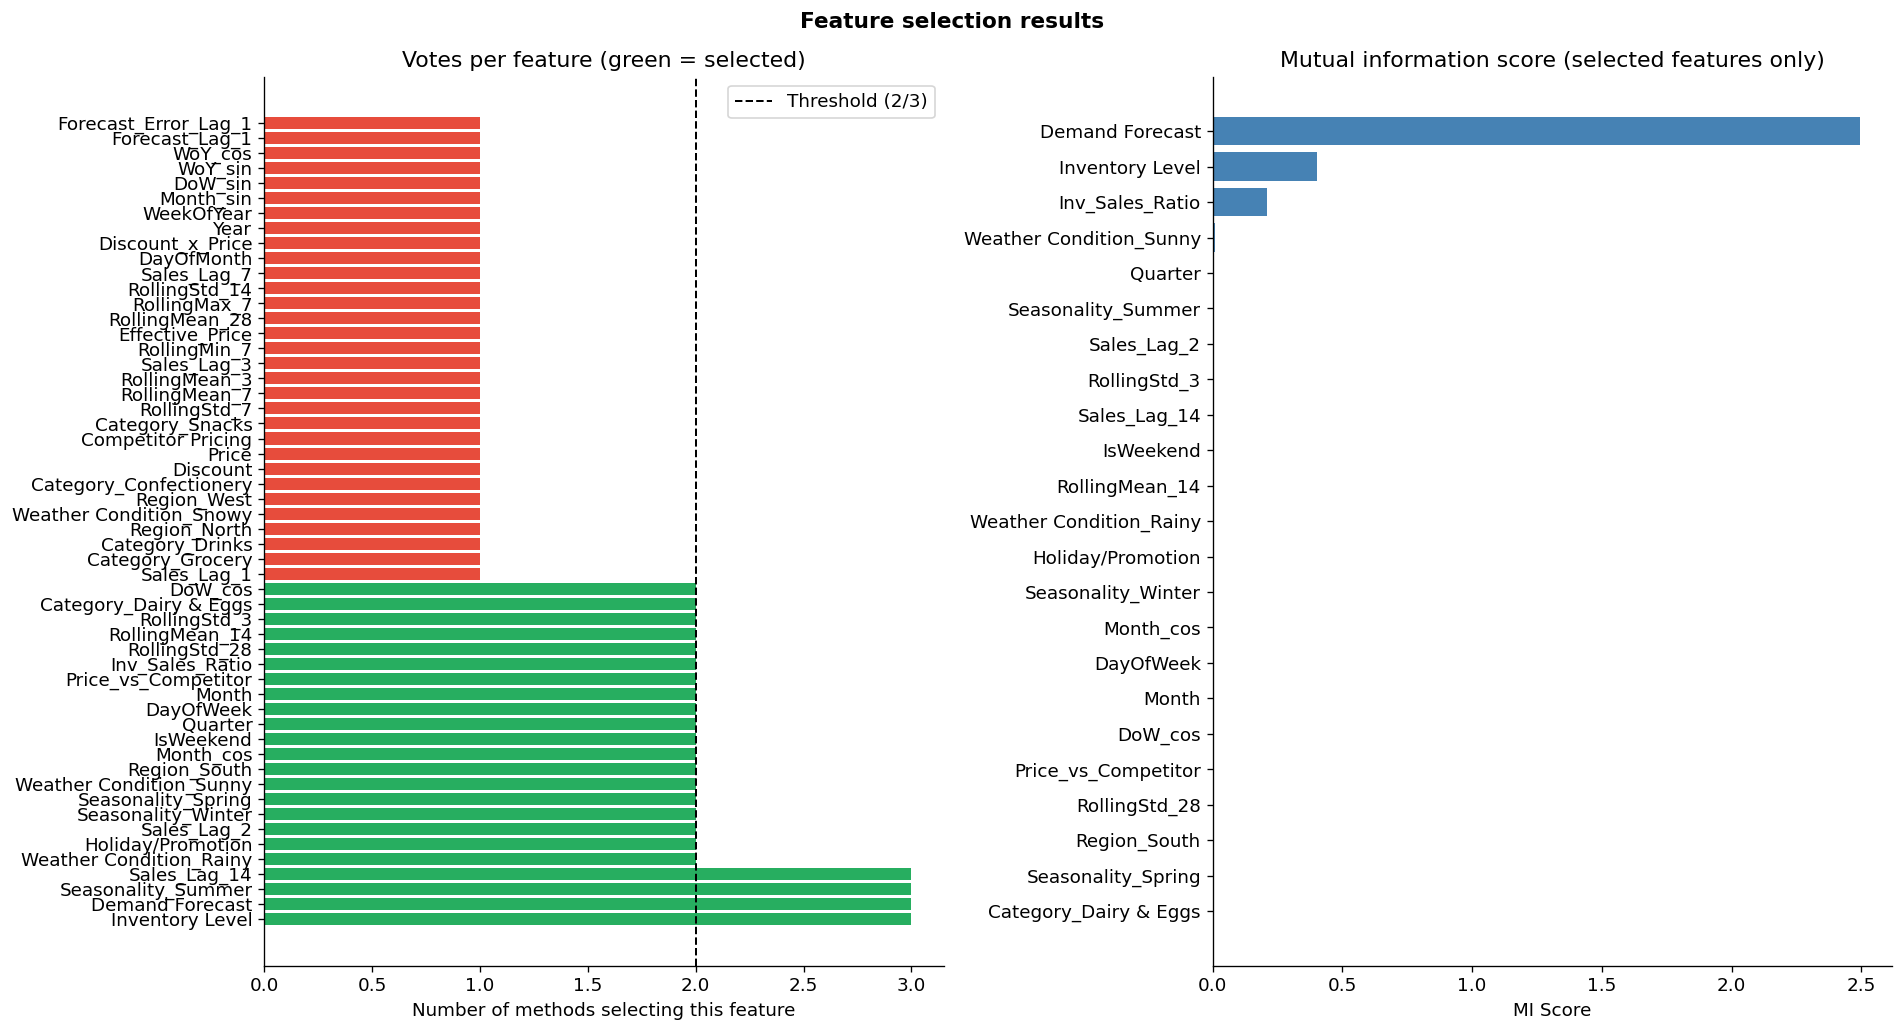

Features removed by selection: ['Price', 'Discount', 'Competitor Pricing', 'Weather Condition_Snowy', 'Region_North', 'Region_West', 'Category_Confectionery', 'Category_Drinks', 'Category_Grocery', 'Category_Snacks', 'Sales_Lag_1', 'Sales_Lag_3', 'Sales_Lag_7', 'RollingMean_3', 'RollingMean_7', 'RollingStd_7', 'RollingStd_14', 'RollingMean_28', 'RollingMax_7', 'RollingMin_7', 'Effective_Price', 'Discount_x_Price', 'DayOfMonth', 'WeekOfYear', 'Year', 'Month_sin', 'DoW_sin', 'WoY_sin', 'WoY_cos', 'Forecast_Lag_1', 'Forecast_Error_Lag_1']


In [51]:
vote_df = (pd.DataFrame([{'Feature': f, 'Votes': v} for f, v in vote_map.items()])
           .sort_values('Votes', ascending=False))
mi_plot = mi_df.set_index('Feature').loc[SELECTED_FEATURES].sort_values('MI_Score', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(SELECTED_FEATURES)*0.38)))
fig.suptitle('Feature selection results', fontsize=13, fontweight='bold')

colors_vote = ['#e74c3c' if v < 2 else '#27ae60' for v in vote_df['Votes']]
axes[0].barh(vote_df['Feature'], vote_df['Votes'], color=colors_vote)
axes[0].axvline(2, color='black', linestyle='--', lw=1.2, label='Threshold (2/3)')
axes[0].set_title('Votes per feature (green = selected)')
axes[0].set_xlabel('Number of methods selecting this feature')
axes[0].legend()

axes[1].barh(mi_plot.index, mi_plot['MI_Score'], color='steelblue')
axes[1].set_title('Mutual information score (selected features only)')
axes[1].set_xlabel('MI Score')

plt.tight_layout()
plt.savefig('feature_selection.png', bbox_inches='tight')
plt.show()

removed = [f for f in CANDIDATE_FEATURES if f not in SELECTED_FEATURES]
print(f'Features removed by selection: {removed}')

---
## 7. Train / Validation / Test Split

Per-entity chronological split (70 / 15 / 15). Each Store+Product pair is split independently in time, preventing sequences from crossing entity boundaries.

In [52]:
SEQ_LEN  = 21
MIN_ROWS = SEQ_LEN + 10

train_parts, val_parts, test_parts = [], [], []
for (store, product), grp in df.groupby(['Store ID', 'Product ID']):
    grp = grp.sort_values('Date').reset_index(drop=True)
    n = len(grp)
    if n < MIN_ROWS:
        continue
    t1 = int(n * 0.70)
    t2 = int(n * 0.85)
    train_parts.append(grp.iloc[:t1])
    val_parts.append(grp.iloc[t1:t2])
    test_parts.append(grp.iloc[t2:])

train_df = pd.concat(train_parts).reset_index(drop=True)
val_df   = pd.concat(val_parts).reset_index(drop=True)
test_df  = pd.concat(test_parts).reset_index(drop=True)

print(f'Training   : {len(train_df):>8,} rows')
print(f'Validation : {len(val_df):>8,} rows')
print(f'Test       : {len(test_df):>8,} rows')
print(f'Features   : {len(SELECTED_FEATURES)}')

Training   :   50,100 rows
Validation :   10,800 rows
Test       :   10,800 rows
Features   : 23


In [53]:
X_train_raw = train_df[SELECTED_FEATURES].values; y_train = train_df[TARGET].values
X_val_raw   = val_df[SELECTED_FEATURES].values;   y_val   = val_df[TARGET].values
X_test_raw  = test_df[SELECTED_FEATURES].values;  y_test  = test_df[TARGET].values

lstm_feat_scaler = MinMaxScaler()
X_train_sc = lstm_feat_scaler.fit_transform(X_train_raw)
X_val_sc   = lstm_feat_scaler.transform(X_val_raw)
X_test_sc  = lstm_feat_scaler.transform(X_test_raw)

target_scaler = MinMaxScaler()
y_train_sc = target_scaler.fit_transform(y_train.reshape(-1,1)).ravel()
y_val_sc   = target_scaler.transform(y_val.reshape(-1,1)).ravel()
y_test_sc  = target_scaler.transform(y_test.reshape(-1,1)).ravel()

print('MinMaxScaler fitted on training partition only.')
print(f'Feature matrix shape : {X_train_raw.shape}')

MinMaxScaler fitted on training partition only.
Feature matrix shape : (50100, 23)


In [54]:
def build_sequences(df_split, X_scaled, y_scaled, seq_len):
    Xs, ys = [], []
    for _, grp in df_split.groupby(['Store ID', 'Product ID']):
        positions = grp.index.tolist()
        if len(positions) <= seq_len:
            continue
        Xg = X_scaled[positions]
        yg = y_scaled[positions]
        for i in range(seq_len, len(positions)):
            Xs.append(Xg[i - seq_len : i])
            ys.append(yg[i])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = build_sequences(train_df, X_train_sc, y_train_sc, SEQ_LEN)
X_val_seq,   y_val_seq   = build_sequences(val_df,   X_val_sc,   y_val_sc,   SEQ_LEN)
X_test_seq,  y_test_seq  = build_sequences(test_df,  X_test_sc,  y_test_sc,  SEQ_LEN)
y_test_actual = target_scaler.inverse_transform(y_test_seq.reshape(-1,1)).ravel()

print(f'LSTM train : {X_train_seq.shape}  (samples, timesteps, features)')
print(f'LSTM val   : {X_val_seq.shape}')
print(f'LSTM test  : {X_test_seq.shape}')

LSTM train : (48000, 21, 23)  (samples, timesteps, features)
LSTM val   : (8700, 21, 23)
LSTM test  : (8700, 21, 23)


In [55]:
def align_xgb_rows(df_split, X_raw, y_arr, seq_len):
    X_out, y_out = [], []
    for _, grp in df_split.groupby(['Store ID', 'Product ID']):
        positions = grp.index.tolist()
        if len(positions) <= seq_len:
            continue
        X_out.append(X_raw[positions[seq_len:]])
        y_out.append(y_arr[positions[seq_len:]])
    return np.vstack(X_out), np.concatenate(y_out)

X_tr_xgb, y_tr_xgb = align_xgb_rows(train_df, X_train_raw, y_train, SEQ_LEN)
X_vl_xgb, y_vl_xgb = align_xgb_rows(val_df,   X_val_raw,   y_val,   SEQ_LEN)
X_te_xgb, y_te_xgb = align_xgb_rows(test_df,  X_test_raw,  y_test,  SEQ_LEN)

assert len(X_tr_xgb) == len(X_train_seq), 'Train alignment failed'
assert len(X_vl_xgb) == len(X_val_seq),   'Val alignment failed'
assert len(X_te_xgb) == len(X_test_seq),  'Test alignment failed'
print('Row alignment confirmed.')
print(f'XGBoost train : {X_tr_xgb.shape}  (raw, unscaled)')

Row alignment confirmed.
XGBoost train : (48000, 23)  (raw, unscaled)


---
## 8. Baseline Models

In [56]:
lag2_idx     = SELECTED_FEATURES.index('Sales_Lag_2')
lag14_idx    = SELECTED_FEATURES.index('Sales_Lag_14')
naive_preds    = X_te_xgb[:, lag2_idx].copy()
seasonal_preds = X_te_xgb[:, lag14_idx].copy()

lr_model = LinearRegression()
lr_model.fit(X_tr_xgb, y_tr_xgb)
lr_preds = lr_model.predict(X_te_xgb)

print(f'Naive (Lag-2) MAE     : {mean_absolute_error(y_test_actual, naive_preds):.2f}')
print(f'Seasonal (Lag-14) MAE : {mean_absolute_error(y_test_actual, seasonal_preds):.2f}')
print(f'Linear Regression MAE : {mean_absolute_error(y_test_actual, lr_preds):.2f}')

Naive (Lag-2) MAE     : 118.86
Seasonal (Lag-14) MAE : 119.84
Linear Regression MAE : 7.50


---
## 9. XGBoost Model

XGBoost receives **raw unscaled** features. Tree-based models partition feature space using threshold comparisons, so monotonic scaling transformations have no effect on the splits or predictions.

In [57]:
xgb_model = XGBRegressor(
    n_estimators          = 800,
    learning_rate         = 0.03,
    max_depth             = 6,
    min_child_weight      = 5,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    colsample_bylevel     = 0.8,
    reg_alpha             = 0.1,
    reg_lambda            = 2.0,
    gamma                 = 0.1,
    early_stopping_rounds = 30,
    eval_metric           = 'mae',
    random_state          = SEED,
    verbosity             = 0,
)

xgb_model.fit(X_tr_xgb, y_tr_xgb, eval_set=[(X_vl_xgb, y_vl_xgb)], verbose=100)
xgb_preds = xgb_model.predict(X_te_xgb)

print(f'\nBest iteration : {xgb_model.best_iteration}')
print(f'XGBoost MAE    : {mean_absolute_error(y_test_actual, xgb_preds):.2f}')
print(f'XGBoost R2     : {r2_score(y_test_actual, xgb_preds):.3f}')

[0]	validation_0-mae:88.74027
[100]	validation_0-mae:10.07808
[200]	validation_0-mae:7.43175
[300]	validation_0-mae:7.35072
[376]	validation_0-mae:7.34766

Best iteration : 346
XGBoost MAE    : 7.27
XGBoost R2     : 0.994


In [58]:
print('Walk-forward cross-validation (5 folds)...')
tscv    = TimeSeriesSplit(n_splits=5)
cv_maes, cv_r2s = [], []
for fold, (tri, vli) in enumerate(tscv.split(X_tr_xgb)):
    m = XGBRegressor(n_estimators=500, learning_rate=0.04, max_depth=6,
                     subsample=0.8, colsample_bytree=0.8,
                     random_state=SEED, verbosity=0)
    m.fit(X_tr_xgb[tri], y_tr_xgb[tri])
    fp = m.predict(X_tr_xgb[vli])
    cv_maes.append(mean_absolute_error(y_tr_xgb[vli], fp))
    cv_r2s.append(r2_score(y_tr_xgb[vli], fp))
    print(f'  Fold {fold+1}  MAE={cv_maes[-1]:.2f}  R2={cv_r2s[-1]:.3f}')
print(f'\nCV MAE : {np.mean(cv_maes):.2f} +/- {np.std(cv_maes):.2f}')
print(f'CV R2  : {np.mean(cv_r2s):.3f} +/- {np.std(cv_r2s):.3f}')

Walk-forward cross-validation (5 folds)...
  Fold 1  MAE=7.59  R2=0.993
  Fold 2  MAE=7.35  R2=0.994
  Fold 3  MAE=7.27  R2=0.994
  Fold 4  MAE=7.32  R2=0.994
  Fold 5  MAE=7.25  R2=0.994

CV MAE : 7.36 +/- 0.12
CV R2  : 0.994 +/- 0.000


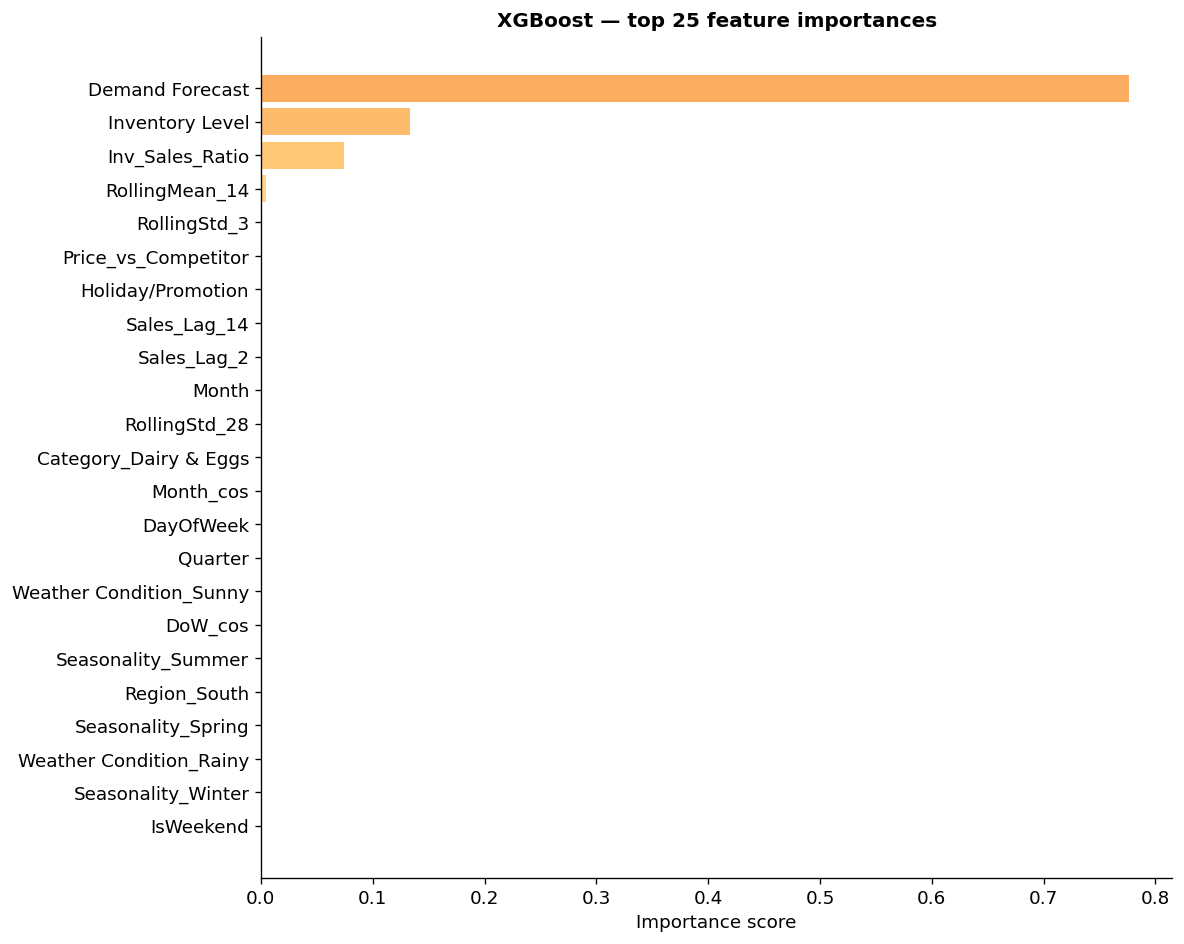

In [59]:
imp_df = (pd.DataFrame({'Feature': SELECTED_FEATURES,
                        'Importance': xgb_model.feature_importances_})
           .sort_values('Importance', ascending=False).head(25))

plt.figure(figsize=(10, 8))
palette = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(imp_df)))
plt.barh(imp_df['Feature'][::-1], imp_df['Importance'][::-1], color=palette[::-1])
plt.xlabel('Importance score')
plt.title('XGBoost — top 25 feature importances', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', bbox_inches='tight')
plt.show()

---
## 10. LSTM Model

A stacked LSTM network to capture sequential demand patterns, seasonal cycles, and temporal dependencies across the 21-day look-back window.

In [60]:
def build_lstm(seq_len, n_features):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(seq_len, n_features)),
        BatchNormalization(),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ], name='lstm_demand_forecaster')
    model.compile(optimizer=Adam(learning_rate=0.001), loss='huber', metrics=['mae'])
    return model

lstm_model = build_lstm(SEQ_LEN, X_train_seq.shape[2])
lstm_model.summary()

Model: "lstm_demand_forecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 21, 128)        │        77,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 21, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 21, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,273 (524.50 KB)

 Trainable params: 133,889 (523.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [61]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_lstm.keras', monitor='val_loss', save_best_only=True, verbose=0),
]

history = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=150, batch_size=256,
    callbacks=callbacks, verbose=1
)

Epoch 1/150
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 0.0349 - mae: 0.2062 - val_loss: 0.0344 - val_mae: 0.1892 - learning_rate: 0.0010
Epoch 2/150
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0257 - mae: 0.1836 - val_loss: 0.0252 - val_mae: 0.1772 - learning_rate: 0.0010
Epoch 3/150
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0251 - mae: 0.1822 - val_loss: 0.0245 - val_mae: 0.1787 - learning_rate: 0.0010
Epoch 4/150
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0249 - mae: 0.1816 - val_loss: 0.0244 - val_mae: 0.1801 - learning_rate: 0.0010
Epoch 5/150
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0246 - mae: 0.1808 - val_loss: 0.0250 - val_mae: 0.1893 - learning_rate: 0.0010
Epoch 6/150
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0245 - mae: 0.1808 - val_loss: 0.0245 - val_mae: 0.1787 - learning_rate: 0.0010
Epoch 7/150
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0245 - mae: 0.1805 - val_loss: 0.0245 - val_mae: 0.1801 - learning_rate:

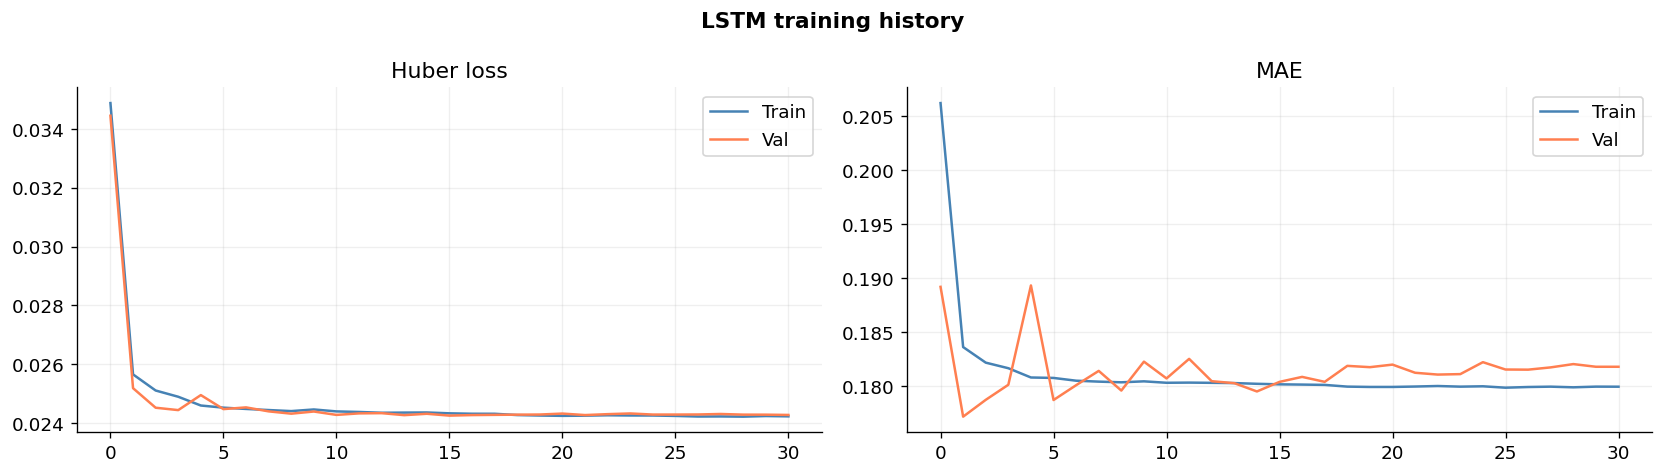

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('LSTM training history', fontsize=13, fontweight='bold')
for ax, key, label in zip(axes, ['loss','mae'], ['Huber loss','MAE']):
    ax.plot(history.history[key],          label='Train', color='steelblue', lw=1.5)
    ax.plot(history.history[f'val_{key}'], label='Val',   color='coral',     lw=1.5)
    ax.set_title(label); ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('lstm_training_history.png', bbox_inches='tight')
plt.show()

In [63]:
lstm_pred_sc = lstm_model.predict(X_test_seq, verbose=0).ravel()
lstm_preds   = np.clip(
    target_scaler.inverse_transform(lstm_pred_sc.reshape(-1,1)).ravel(), 0, None)
print(f'LSTM MAE : {mean_absolute_error(y_test_actual, lstm_preds):.2f}')
print(f'LSTM R2  : {r2_score(y_test_actual, lstm_preds):.3f}')

LSTM MAE : 88.76
LSTM R2  : -0.001


---
## 11. Hybrid Ensemble — Ridge Stacking Meta-Learner

A Ridge regression is trained on **validation-set predictions** from both models. It learns the optimal linear combination and automatically down-weights whichever model performed worse during validation.

In [64]:
lstm_val_sc = lstm_model.predict(X_val_seq, verbose=0).ravel()
lstm_val_p  = np.clip(target_scaler.inverse_transform(lstm_val_sc.reshape(-1,1)).ravel(), 0, None)
xgb_val_p   = xgb_model.predict(X_vl_xgb)

assert len(lstm_val_p) == len(xgb_val_p)

meta_learner = Ridge(alpha=1.0)
meta_learner.fit(np.column_stack([lstm_val_p, xgb_val_p]), y_vl_xgb)

print('Ridge stacking meta-learner fitted.')
print(f'  LSTM coefficient   : {meta_learner.coef_[0]:.4f}')
print(f'  XGBoost coefficient: {meta_learner.coef_[1]:.4f}')
print(f'  Intercept          : {meta_learner.intercept_:.4f}')

Ridge stacking meta-learner fitted.
  LSTM coefficient   : -0.0130
  XGBoost coefficient: 1.0021
  Intercept          : 1.3277


In [65]:
ensemble_preds = np.clip(
    meta_learner.predict(np.column_stack([lstm_preds, xgb_preds])), 0, None)
print(f'Ensemble MAE : {mean_absolute_error(y_test_actual, ensemble_preds):.2f}')
print(f'Ensemble R2  : {r2_score(y_test_actual, ensemble_preds):.3f}')

Ensemble MAE : 7.27
Ensemble R2  : 0.994


---
## 12. Evaluation and Comparison

In [66]:
def smape(yt, yp):
    d = (np.abs(yt) + np.abs(yp)) / 2
    m = d > 0
    return np.mean(np.abs(yt[m] - yp[m]) / d[m]) * 100

def mape(yt, yp):
    m = yt > 0
    return np.mean(np.abs((yt[m] - yp[m]) / yt[m])) * 100

def forecast_accuracy(yt, yp):
    return max(0, (1 - np.sum(np.abs(yt - yp)) / (np.sum(np.abs(yt)) + 1e-8)) * 100)

def evaluate(yt, yp, name):
    mse_val = mean_squared_error(yt, yp)
    return {
        'Model'       : name,
        'MAE'         : mean_absolute_error(yt, yp),
        'RMSE'        : np.sqrt(mse_val),
        'R2'          : r2_score(yt, yp),
        'MAPE_%'      : mape(yt, yp),
        'SMAPE_%'     : smape(yt, yp),
        'Accuracy_%'  : forecast_accuracy(yt, yp),
    }

y_true = y_test_actual
results = [
    evaluate(y_true, naive_preds,    'Naive (Lag-1)'),
    evaluate(y_true, seasonal_preds, 'Seasonal (Lag-7)'),
    evaluate(y_true, lr_preds,       'Linear Regression'),
    evaluate(y_true, xgb_preds,      'XGBoost'),
    evaluate(y_true, lstm_preds,     'LSTM'),
    evaluate(y_true, ensemble_preds, 'Hybrid Ensemble'),
]

res_df = pd.DataFrame(results).set_index('Model').round(3)

print()
print('=' * 75)
print('           MODEL EVALUATION  -  TEST SET')
print('=' * 75)
print(res_df.to_string())
print('=' * 75)
print(f'Best MAE      : {res_df["MAE"].idxmin()}')
print(f'Best R2       : {res_df["R2"].idxmax()}')
print(f'Best Accuracy : {res_df["Accuracy_%"].idxmax()}')


           MODEL EVALUATION  -  TEST SET
                       MAE     RMSE     R2   MAPE_%  SMAPE_%  Accuracy_%
Model                                                                   
Naive (Lag-1)      118.859  153.121 -1.014  350.830   91.687      13.235
Seasonal (Lag-7)   119.837  153.868 -1.034  376.846   92.396      12.521
Linear Regression    7.503    8.686  0.994   23.118   17.240      94.523
XGBoost              7.274    8.546  0.994   20.029   13.988      94.690
LSTM                88.757  107.959 -0.001  341.599   71.481      35.209
Hybrid Ensemble      7.270    8.544  0.994   19.431   14.005      94.693
Best MAE      : Hybrid Ensemble
Best R2       : Linear Regression
Best Accuracy : Hybrid Ensemble


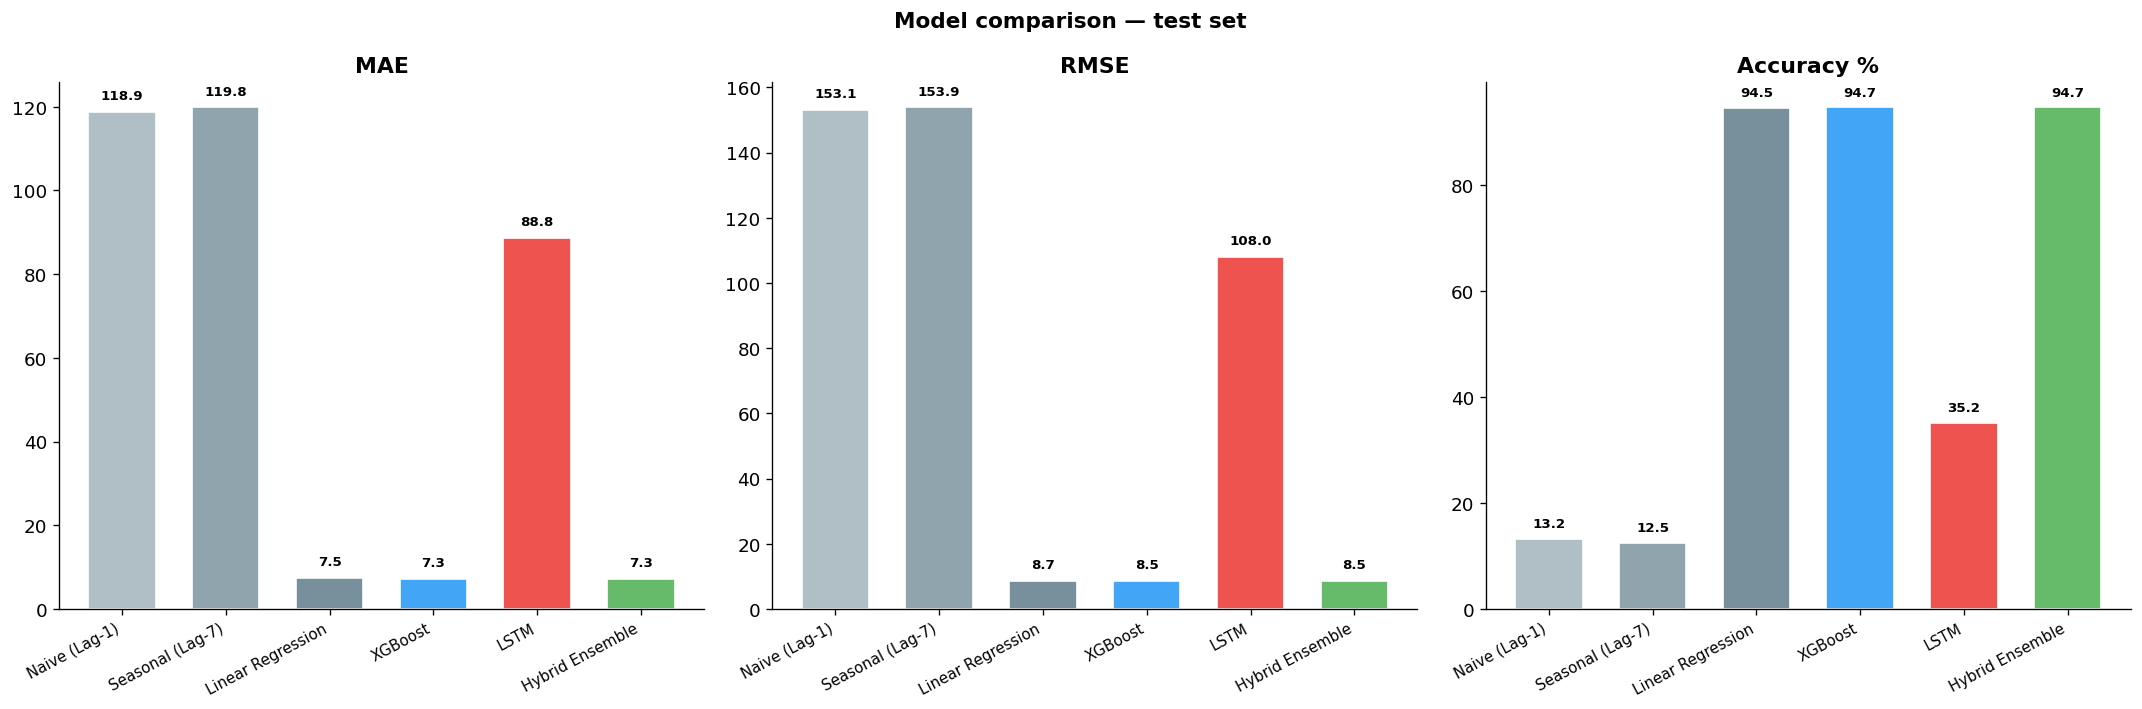

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model comparison — test set', fontsize=13, fontweight='bold')

palette = ['#b0bec5','#90a4ae','#78909c','#42a5f5','#ef5350','#66bb6a']
models  = res_df.index.tolist()
xs      = range(len(models))

for ax, metric in zip(axes, ['MAE', 'RMSE', 'Accuracy_%']):
    vals = res_df[metric].values
    bars = ax.bar(xs, vals, color=palette, edgecolor='white', width=0.65)
    ax.set_xticks(list(xs))
    ax.set_xticklabels(models, rotation=28, ha='right', fontsize=9)
    ax.set_title(metric.replace('_',' '), fontweight='bold')
    ax.axhline(0, color='black', lw=0.5, alpha=0.4)
    for bar, v in zip(bars, vals):
        off = 0.02 * (max(vals) - min(vals) + 1e-5)
        ax.text(bar.get_x() + bar.get_width()/2,
                v + off if v >= 0 else v - off,
                f'{v:.1f}', ha='center',
                va='bottom' if v >= 0 else 'top', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

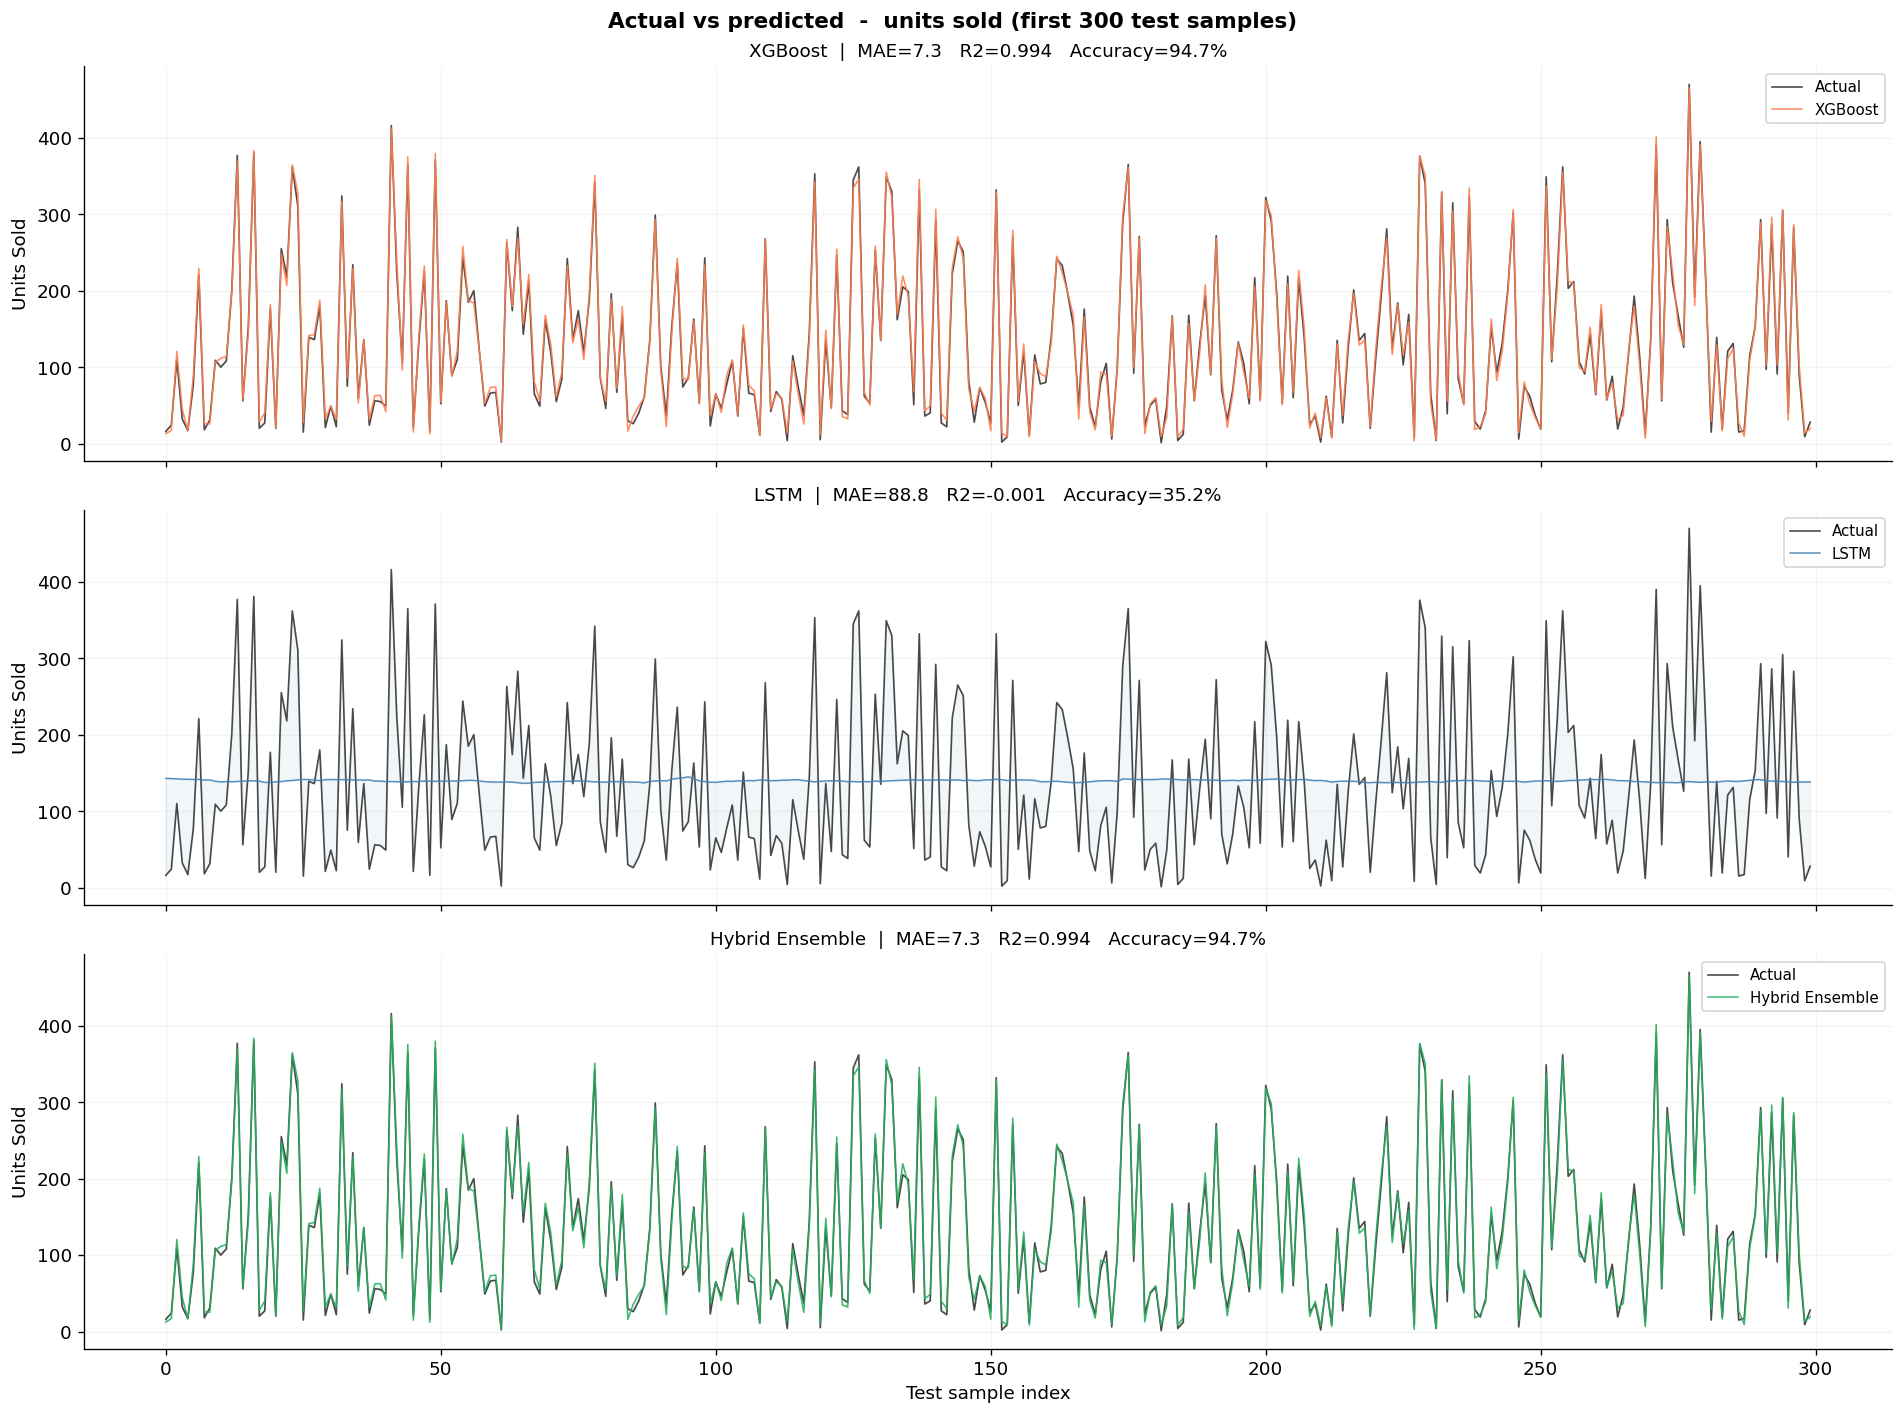

In [68]:
N = min(300, len(y_true))
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle('Actual vs predicted  -  units sold (first 300 test samples)',
             fontsize=13, fontweight='bold')

for ax, (name, preds, colour) in zip(axes, [
    ('XGBoost',        xgb_preds,      'coral'),
    ('LSTM',           lstm_preds,     'steelblue'),
    ('Hybrid Ensemble', ensemble_preds, '#27ae60'),
]):
    ax.plot(y_true[:N], color='black', lw=1.0, label='Actual', alpha=0.7)
    ax.plot(preds[:N],  color=colour,  lw=0.9, label=name,     alpha=0.9)
    ax.fill_between(range(N), y_true[:N], preds[:N], alpha=0.07, color=colour)
    ax.set_title(
        f'{name}  |  MAE={res_df.loc[name,"MAE"]:.1f}   '
        f'R2={res_df.loc[name,"R2"]:.3f}   '
        f'Accuracy={res_df.loc[name,"Accuracy_%"]:.1f}%', fontsize=11)
    ax.set_ylabel('Units Sold'); ax.legend(fontsize=9); ax.grid(alpha=0.15)

axes[-1].set_xlabel('Test sample index')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', bbox_inches='tight')
plt.show()

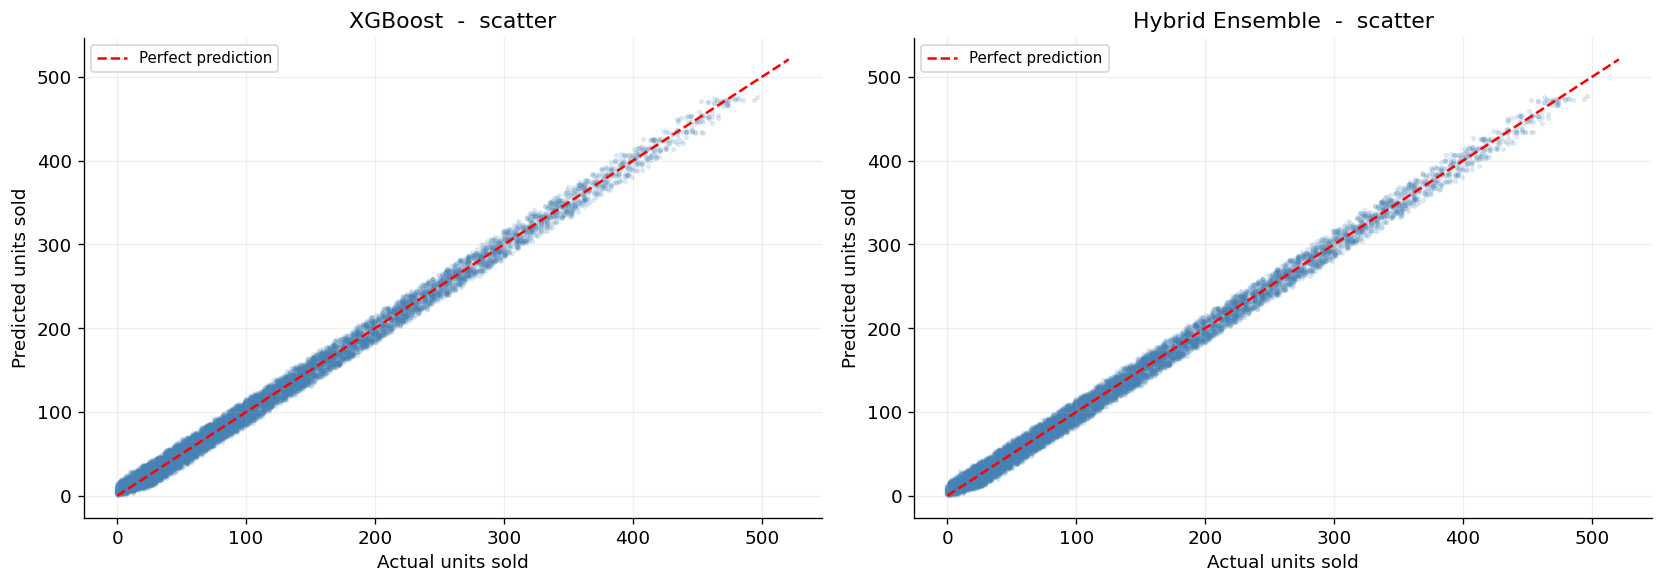

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, preds) in zip(axes, [('XGBoost', xgb_preds),('Hybrid Ensemble', ensemble_preds)]):
    ax.scatter(y_true, preds, alpha=0.12, s=5, color='steelblue')
    lim = max(y_true.max(), preds.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual units sold'); ax.set_ylabel('Predicted units sold')
    ax.set_title(f'{name}  -  scatter')
    ax.legend(fontsize=9); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('scatter_actual_vs_predicted.png', bbox_inches='tight')
plt.show()

---
## 13. SHAP Explainability

> SHAP is applied to the XGBoost component. LSTM interpretability via attention mechanisms is outside this scope. The XGBoost SHAP values explain how each feature shifts predictions away from the average.

In [70]:
print('Computing SHAP values...')
explainer   = shap.TreeExplainer(xgb_model)
N_SHAP      = min(1500, len(X_te_xgb))
shap_values = explainer.shap_values(X_te_xgb[:N_SHAP])
shap_df     = pd.DataFrame(X_te_xgb[:N_SHAP], columns=SELECTED_FEATURES)
print(f'SHAP values computed for {N_SHAP} samples.')

Computing SHAP values...
SHAP values computed for 1500 samples.


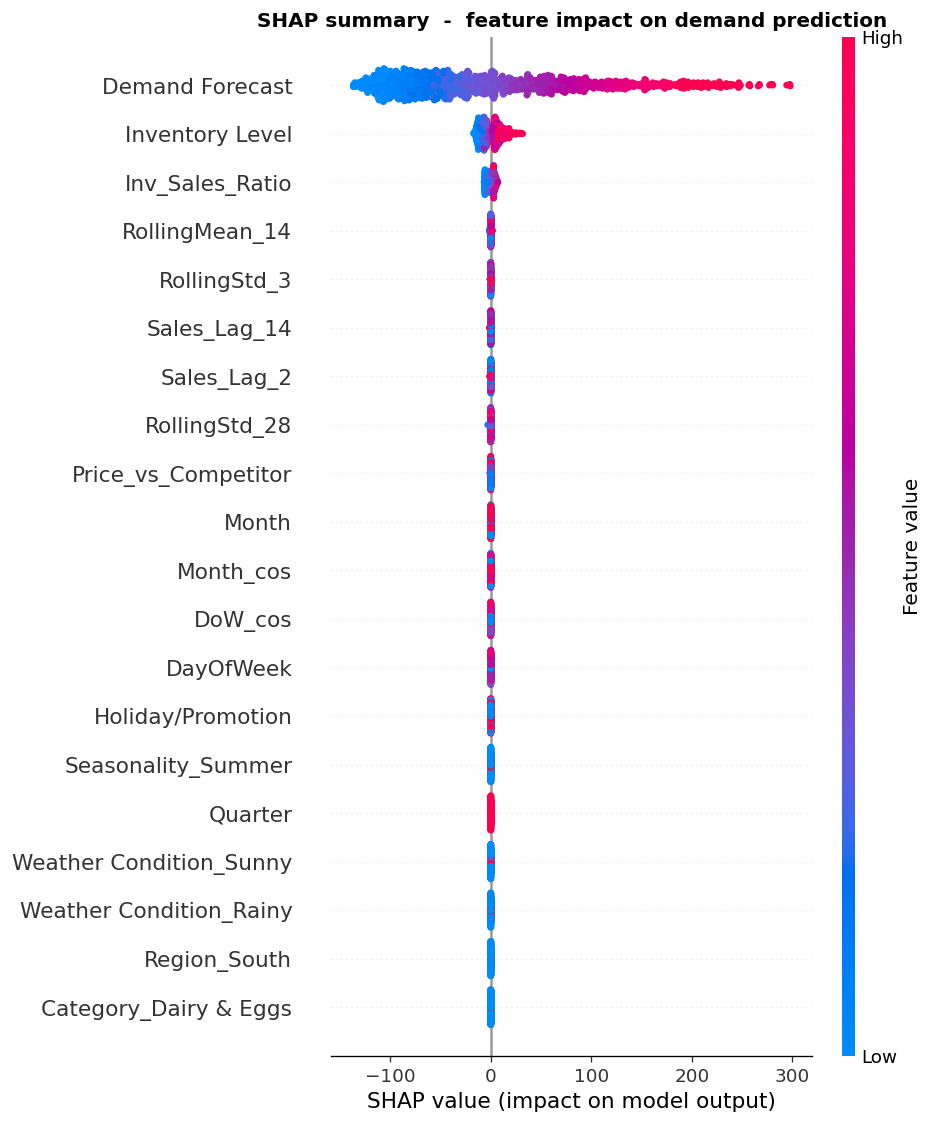

In [71]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, shap_df, plot_type='dot', max_display=20, show=False)
plt.title('SHAP summary  -  feature impact on demand prediction', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight')
plt.show()

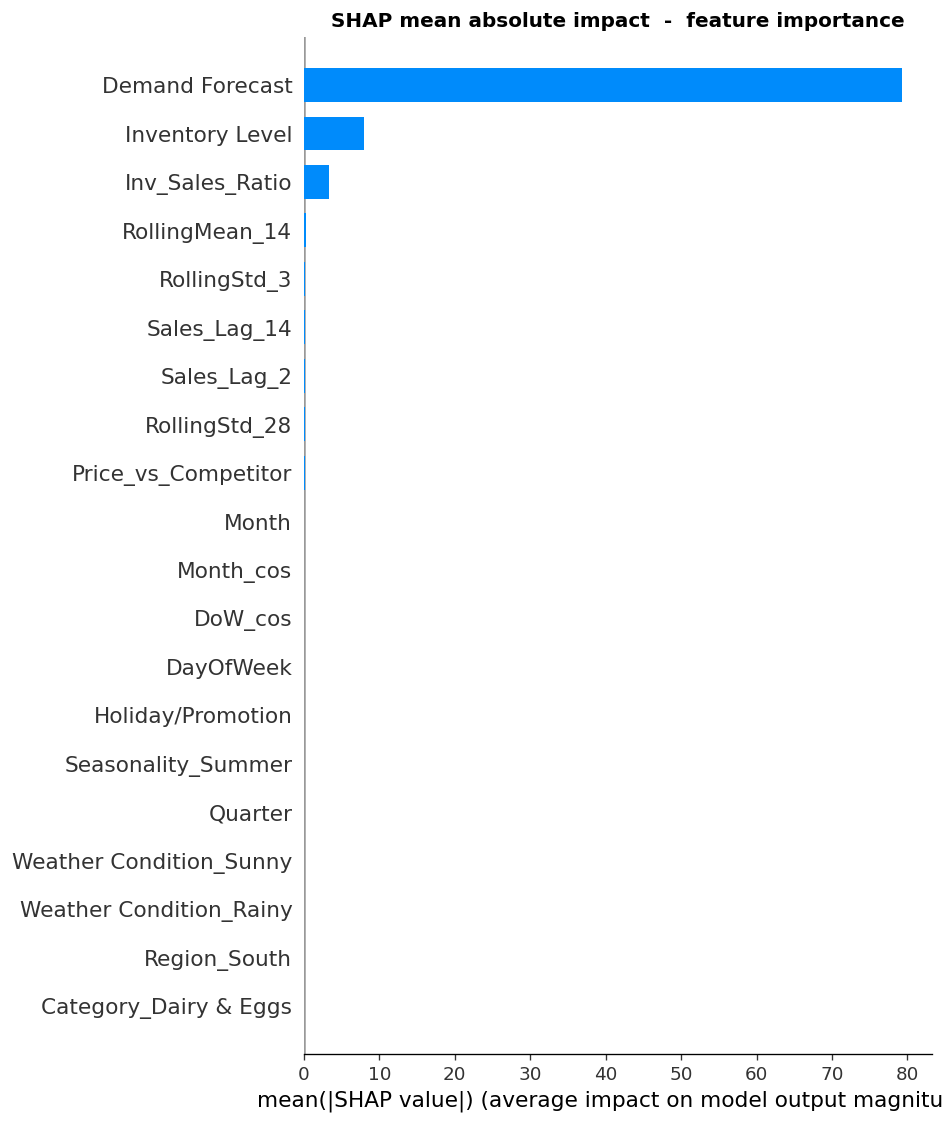

In [72]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, shap_df, plot_type='bar', max_display=20, show=False)
plt.title('SHAP mean absolute impact  -  feature importance', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', bbox_inches='tight')
plt.show()

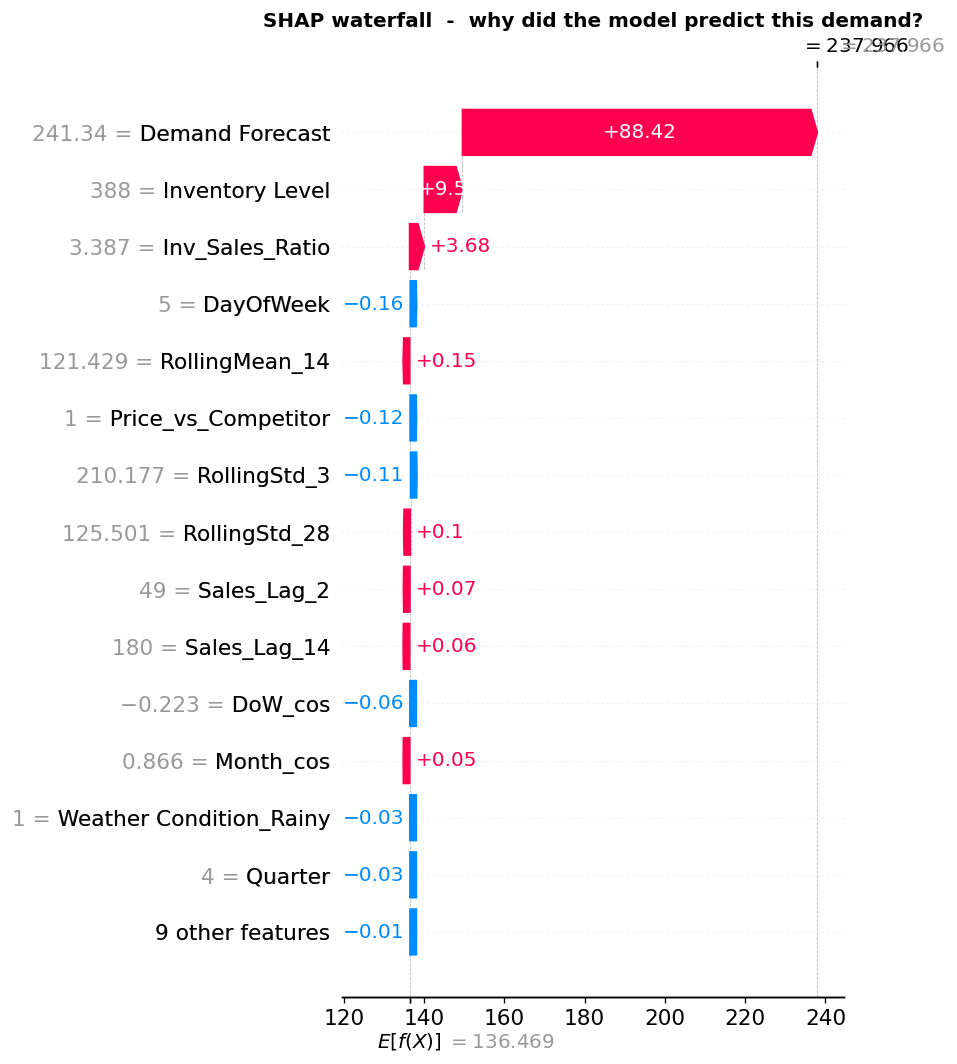

Actual demand     : 223 units
XGBoost predicted : 238 units
Ensemble predicted: 238 units


In [73]:
EXPLAIN_IDX = 42
exp = shap.Explanation(
    values=shap_values[EXPLAIN_IDX],
    base_values=explainer.expected_value,
    data=shap_df.iloc[EXPLAIN_IDX].values,
    feature_names=SELECTED_FEATURES
)
plt.figure(figsize=(10, 6))
shap.waterfall_plot(exp, max_display=15, show=False)
plt.title('SHAP waterfall  -  why did the model predict this demand?',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall.png', bbox_inches='tight')
plt.show()
print(f'Actual demand     : {y_test_actual[EXPLAIN_IDX]:.0f} units')
print(f'XGBoost predicted : {xgb_preds[EXPLAIN_IDX]:.0f} units')
print(f'Ensemble predicted: {ensemble_preds[EXPLAIN_IDX]:.0f} units')

---
## 14. Date-Range Forecasting (Recursive)

Forecasts daily demand for any date range using historical demand patterns.

**How it works:** Each day's prediction becomes the next day's lag feature. The model rolls forward one day at a time.

**Recommended date range:** Within 2022-01-01 to 2024-01-01 for highest accuracy. Short extrapolation up to ~14 days beyond the data end is acceptable.

**Input you need to provide per forecast:**
- `from_date`, `to_date`
- Business context: price, discount, inventory level, weather, region, category, seasonality, holiday flag

In [74]:
def build_feature_row(date, history_sales, price, discount, inventory_level,
                      weather, region, category, seasonality, holiday_promotion,
                      competitor_pricing=1.0, demand_forecast=None):
    date  = pd.Timestamp(date)
    sales = np.array(history_sales, dtype=float)
    lag   = lambda n: float(sales[-n]) if len(sales) >= n else 0.0
    rmean = lambda w: float(np.mean(sales[-w:])) if len(sales) >= 1 else 0.0
    rstd  = lambda w: float(np.std(sales[-w:]))  if len(sales) >= 2 else 0.0
    rmax  = lambda w: float(np.max(sales[-w:]))  if len(sales) >= 1 else 0.0
    rmin  = lambda w: float(np.min(sales[-w:]))  if len(sales) >= 1 else 0.0
    rm7  = rmean(7)
    dow  = date.dayofweek
    mon  = date.month
    woy  = date.isocalendar()[1]
    if demand_forecast is None:
        demand_forecast = rmean(7)  # fallback: rolling average as proxy
    lag1_val = lag(1)
    base = {
        'Demand Forecast'     : demand_forecast,
        'Forecast_Lag_1'      : lag(1),
        'Forecast_Error_Lag_1': lag1_val - demand_forecast,
        'Inventory Level'     : inventory_level,
        'Price'               : price,
        'Discount'            : discount,
        'Holiday/Promotion'   : holiday_promotion,
        'Competitor Pricing'  : competitor_pricing,
        'Sales_Lag_1'         : lag(1),  'Sales_Lag_2': lag(2),  'Sales_Lag_3': lag(3),
        'Sales_Lag_7'         : lag(7),  'Sales_Lag_14': lag(14),
        'RollingMean_3'       : rmean(3), 'RollingMean_7': rm7,
        'RollingMean_14'      : rmean(14),'RollingMean_28': rmean(28),
        'RollingStd_3'        : rstd(3),  'RollingStd_7': rstd(7),
        'RollingStd_14'       : rstd(14), 'RollingStd_28': rstd(28),
        'RollingMax_7'        : rmax(7),  'RollingMin_7': rmin(7),
        'Effective_Price'     : price * (1 - discount / 100),
        'Price_vs_Competitor' : price / (competitor_pricing + 1e-5),
        'Inv_Sales_Ratio'     : min(inventory_level / (rm7 + 1), 50),
        'Discount_x_Price'    : discount * price,
        'DayOfWeek'           : dow,  'DayOfMonth': date.day, 'Month': mon,
        'Quarter'             : date.quarter, 'WeekOfYear': woy,
        'IsWeekend'           : int(dow >= 5), 'Year': date.year,
        'Month_sin': np.sin(2*np.pi*mon/12), 'Month_cos': np.cos(2*np.pi*mon/12),
        'DoW_sin'  : np.sin(2*np.pi*dow/7),  'DoW_cos':   np.cos(2*np.pi*dow/7),
        'WoY_sin'  : np.sin(2*np.pi*woy/52), 'WoY_cos':   np.cos(2*np.pi*woy/52),
    }
    nominal_input = pd.DataFrame([{
        'Weather Condition': weather, 'Region': region,
        'Category': category, 'Seasonality': seasonality
    }])[NOMINAL]
    ohe_row = ohe.transform(nominal_input.astype(str))[0]
    ohe_map = dict(zip(ohe.get_feature_names_out(NOMINAL), ohe_row))
    combined = {**base, **ohe_map}
    return np.array([combined.get(f, 0.0) for f in SELECTED_FEATURES], dtype=float)

print('Feature row builder ready.')

Feature row builder ready.


In [75]:
def forecast_date_range(from_date, to_date, price, discount, inventory_level,
                        weather='Sunny', region='North', category='Drinks',
                        seasonality='Summer', holiday_promotion=0,
                        competitor_pricing=1.0, demand_forecast=None,
                        seed_store='S001', seed_product='PROD-001'):
    from_date  = pd.Timestamp(from_date)
    to_date    = pd.Timestamp(to_date)
    date_range = pd.date_range(start=from_date, end=to_date, freq='D')

    seed_hist = (df[(df['Store ID']==seed_store) & (df['Product ID']==seed_product)]
                 .sort_values('Date').tail(60)['Units Sold'].tolist())
    if len(seed_hist) < SEQ_LEN:
        raise ValueError(f'Need {SEQ_LEN} seed rows, got {len(seed_hist)}')

    rolling_sales = list(seed_hist)

    seed_rows = []
    for i, _ in enumerate(seed_hist[-SEQ_LEN:]):
        r = build_feature_row(
            date=from_date - pd.Timedelta(days=SEQ_LEN-i),
            history_sales=seed_hist[:max(1, len(seed_hist)-SEQ_LEN+i)],
            price=price, discount=discount, inventory_level=inventory_level,
            weather=weather, region=region, category=category,
            seasonality=seasonality, holiday_promotion=holiday_promotion,
            competitor_pricing=competitor_pricing,
            demand_forecast=demand_forecast)
        seed_rows.append(r)

    lstm_window = list(lstm_feat_scaler.transform(np.array(seed_rows)))
    records = []

    for forecast_date in date_range:
        feat_raw = build_feature_row(
            date=forecast_date, history_sales=rolling_sales,
            price=price, discount=discount, inventory_level=inventory_level,
            weather=weather, region=region, category=category,
            seasonality=seasonality, holiday_promotion=holiday_promotion,
            competitor_pricing=competitor_pricing,
            demand_forecast=demand_forecast)

        xgb_p = float(np.clip(xgb_model.predict(feat_raw.reshape(1,-1))[0], 0, None))

        feat_sc = lstm_feat_scaler.transform(feat_raw.reshape(1,-1))[0]
        lstm_window.append(feat_sc)
        lstm_window = lstm_window[-SEQ_LEN:]
        lstm_sc_p   = lstm_model.predict(np.array(lstm_window).reshape(1,SEQ_LEN,-1), verbose=0)[0,0]
        lstm_p      = float(np.clip(target_scaler.inverse_transform([[lstm_sc_p]])[0,0], 0, None))

        ens_p = float(np.clip(meta_learner.predict([[lstm_p, xgb_p]])[0], 0, None))

        records.append({
            'Date'              : forecast_date,
            'Day'               : forecast_date.strftime('%A'),
            'IsWeekend'         : int(forecast_date.dayofweek >= 5),
            'LSTM_Forecast'     : round(lstm_p, 1),
            'XGBoost_Forecast'  : round(xgb_p, 1),
            'Ensemble_Forecast' : round(ens_p, 1),
        })
        rolling_sales.append(ens_p)
        rolling_sales = rolling_sales[-60:]

    return pd.DataFrame(records)

print('Recursive forecaster ready.')

Recursive forecaster ready.


In [76]:
# ---- configure your forecast here -------------------------------------------
FROM_DATE        = '2023-11-01'
TO_DATE          = '2023-11-30'
PRICE            = 0.85
DISCOUNT         = 10
INVENTORY        = 300
WEATHER          = 'Rainy'    # Sunny / Rainy / Cloudy / Snowy
REGION           = 'North'    # North / South / East / West
CATEGORY         = 'Drinks'   # Drinks / Snacks / Confectionery / Bakery & Bread / Dairy & Eggs / Grocery
SEASONALITY      = 'Autumn'   # Spring / Summer / Autumn / Winter
HOLIDAY          = 0          # 0 or 1
DEMAND_FORECAST  = None       # Set to a float (e.g. 120.0) if upstream forecast is available; None uses rolling mean fallback
# ---- end configuration -------------------------------------------------------

forecast_df = forecast_date_range(
    from_date=FROM_DATE, to_date=TO_DATE,
    price=PRICE, discount=DISCOUNT, inventory_level=INVENTORY,
    weather=WEATHER, region=REGION, category=CATEGORY,
    seasonality=SEASONALITY, holiday_promotion=HOLIDAY,
    demand_forecast=DEMAND_FORECAST,
)

print(f'Forecast  {FROM_DATE}  to  {TO_DATE}')
print()
print(forecast_df.to_string(index=False))

Forecast  2023-11-01  to  2023-11-30

      Date       Day  IsWeekend  LSTM_Forecast  XGBoost_Forecast  Ensemble_Forecast
2023-11-01 Wednesday          0          134.6              78.7               78.5
2023-11-02  Thursday          0          134.8              84.6               84.3
2023-11-03    Friday          0          134.8              67.1               66.8
2023-11-04  Saturday          1          135.1              68.2               67.9
2023-11-05    Sunday          1          135.0              54.3               53.9
2023-11-06    Monday          0          134.9              58.4               58.1
2023-11-07   Tuesday          0          135.2              60.6               60.3
2023-11-08 Wednesday          0          135.3              62.1               61.8
2023-11-09  Thursday          0          135.4              60.6               60.3
2023-11-10    Friday          0          135.3              56.9               56.6
2023-11-11  Saturday          1       

In [77]:
total = forecast_df['Ensemble_Forecast'].sum()
avg   = forecast_df['Ensemble_Forecast'].mean()
peak  = forecast_df.loc[forecast_df['Ensemble_Forecast'].idxmax()]
low   = forecast_df.loc[forecast_df['Ensemble_Forecast'].idxmin()]
wknd  = forecast_df[forecast_df['IsWeekend']==1]['Ensemble_Forecast'].mean()
wkday = forecast_df[forecast_df['IsWeekend']==0]['Ensemble_Forecast'].mean()

print('=' * 54)
print(f'  FORECAST SUMMARY  {FROM_DATE}  to  {TO_DATE}')
print('=' * 54)
print(f'  Total demand forecast  : {total:,.0f} units')
print(f'  Daily average          : {avg:.1f} units')
print(f'  Peak day  : {peak["Date"].date()} ({peak["Day"]}) - {peak["Ensemble_Forecast"]:.0f} units')
print(f'  Lowest day: {low["Date"].date()} ({low["Day"]}) - {low["Ensemble_Forecast"]:.0f} units')
print(f'  Avg weekend demand     : {wknd:.1f} units')
print(f'  Avg weekday demand     : {wkday:.1f} units')
print('=' * 54)

  FORECAST SUMMARY  2023-11-01  to  2023-11-30
  Total demand forecast  : 1,487 units
  Daily average          : 49.6 units
  Peak day  : 2023-11-02 (Thursday) - 84 units
  Lowest day: 2023-11-30 (Thursday) - 27 units
  Avg weekend demand     : 49.0 units
  Avg weekday demand     : 49.8 units


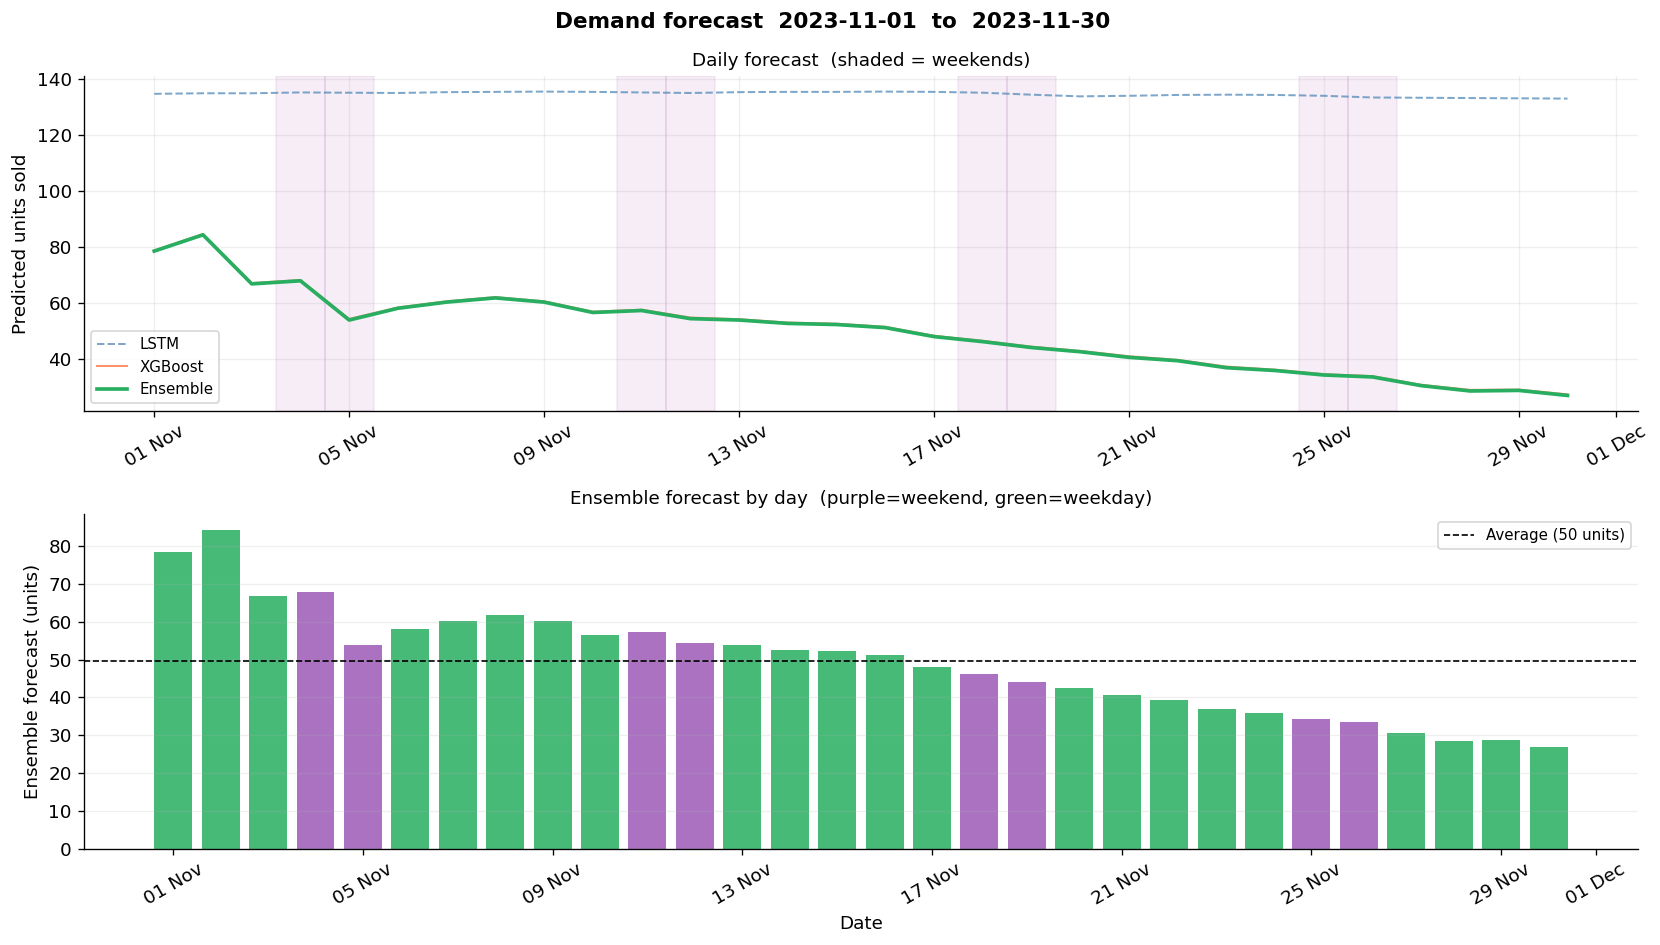

Forecast saved: forecast_2023-11-01_2023-11-30.csv


In [78]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle(f'Demand forecast  {FROM_DATE}  to  {TO_DATE}', fontsize=13, fontweight='bold')

axes[0].plot(forecast_df['Date'], forecast_df['LSTM_Forecast'],
             label='LSTM', color='steelblue', lw=1.2, linestyle='--', alpha=0.7)
axes[0].plot(forecast_df['Date'], forecast_df['XGBoost_Forecast'],
             label='XGBoost', color='coral', lw=1.2, alpha=0.85)
axes[0].plot(forecast_df['Date'], forecast_df['Ensemble_Forecast'],
             label='Ensemble', color='#27ae60', lw=2.2)
for _, row in forecast_df[forecast_df['IsWeekend']==1].iterrows():
    axes[0].axvspan(row['Date']-pd.Timedelta(hours=12), row['Date']+pd.Timedelta(hours=12),
                    alpha=0.07, color='purple')
axes[0].set_ylabel('Predicted units sold')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.2)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_title('Daily forecast  (shaded = weekends)', fontsize=11)

bar_colors = ['#9b59b6' if w else '#27ae60' for w in forecast_df['IsWeekend']]
axes[1].bar(forecast_df['Date'], forecast_df['Ensemble_Forecast'],
            color=bar_colors, width=0.8, alpha=0.85)
axes[1].axhline(avg, color='black', linestyle='--', lw=1, label=f'Average ({avg:.0f} units)')
axes[1].set_ylabel('Ensemble forecast (units)')
axes[1].set_xlabel('Date')
axes[1].legend(fontsize=9); axes[1].grid(axis='y', alpha=0.2)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_title('Ensemble forecast by day  (purple=weekend, green=weekday)', fontsize=11)

plt.tight_layout()
plt.savefig('forecast_output.png', bbox_inches='tight')
plt.show()

csv_name = f'forecast_{FROM_DATE}_{TO_DATE}.csv'
forecast_df.to_csv(csv_name, index=False)
print(f'Forecast saved: {csv_name}')

---
## 15. Save All Artefacts

In [79]:
SAVE_DIR = 'saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

lstm_model.save(f'{SAVE_DIR}/lstm_model.keras')
joblib.dump(xgb_model,          f'{SAVE_DIR}/xgb_model.pkl')
joblib.dump(meta_learner,        f'{SAVE_DIR}/meta_learner.pkl')
joblib.dump(lstm_feat_scaler,    f'{SAVE_DIR}/lstm_feature_scaler.pkl')
joblib.dump(target_scaler,       f'{SAVE_DIR}/target_scaler.pkl')
joblib.dump(le_store,            f'{SAVE_DIR}/le_store.pkl')
joblib.dump(le_product,          f'{SAVE_DIR}/le_product.pkl')
joblib.dump(ohe,                 f'{SAVE_DIR}/ohe_encoder.pkl')
joblib.dump({
    'SELECTED_FEATURES' : SELECTED_FEATURES,
    'NOMINAL'           : NOMINAL,
    'SEQ_LEN'           : SEQ_LEN,
    'TARGET'            : TARGET,
    'SEED'              : SEED,
}, f'{SAVE_DIR}/config.pkl')

print(f'Artefacts saved to ./{SAVE_DIR}/')
print()
for fname in sorted(os.listdir(SAVE_DIR)):
    kb = os.path.getsize(os.path.join(SAVE_DIR, fname)) / 1024
    print(f'  {fname:<35} {kb:>8.1f} KB')

Artefacts saved to ./saved_models/

  config.pkl                               0.5 KB
  le_product.pkl                           0.7 KB
  le_store.pkl                             0.5 KB
  lstm_feature_scaler.pkl                  1.6 KB
  lstm_model.keras                      1627.8 KB
  meta_learner.pkl                         0.5 KB
  ohe_encoder.pkl                          2.1 KB
  target_scaler.pkl                        0.7 KB
  xgb_model.pkl                         1663.0 KB


In [80]:
from google.colab import files
for fname in sorted(os.listdir(SAVE_DIR)):
    fpath = os.path.join(SAVE_DIR, fname)
    files.download(fpath)
    print(f'Downloaded : {fpath}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded : saved_models/config.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded : saved_models/target_scaler.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded : saved_models/xgb_model.pkl
